# AI vs Human Content Detection
Yalnızca **ham metin** kullanılarak AI-üretilmiş / insan-yazımı içerik sınıflandırması.

**Leakage önleme stratejisi:**
1. Her veri setinde sütun bazlı leakage denetimi yapılır (label ile korelasyon + unique değer analizi)
2. Leakage taşıyan sütunlar özellik olarak kullanılmaz; yalnızca `content` / `text` ham metni kullanılır
3. Metin içindeki doğrudan etiket ifadeleri (`(AI-generated)`, `written by AI` vb.) **regex ile kaldırılır** — tüm kelime listesi yerine hedefe yönelik kalıplar kullanılır
4. TF-IDF yalnızca eğitim verisi üzerinde `fit` edilir

## Gerekli Kütüphaneler

In [21]:
import torch

print("GPU Kullanılabilir mi?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Aktif GPU Modeli:", torch.cuda.get_device_name(0))

GPU Kullanılabilir mi?: True
Aktif GPU Modeli: NVIDIA A100-SXM4-40GB


In [22]:
!pip install opendatasets -q

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from scipy.stats import pointbiserialr
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## Yardımcı Fonksiyonlar

In [23]:
# ── Sütun leakage denetimi ─────────────────────────────────────────────────
def audit_columns(df, label_col, text_col, dataset_name="Dataset"):
    """
    Her sütun için label ile ilişkisini raporlar.
    - Kategorik sütunlar: unique değerlerin label'a göre dağılımı
    - Sayısal sütunlar  : Point-Biserial korelasyon
    Yüksek korelasyon veya label'a özgü unique değerler sızıntı işaretidir.
    """
    print(f"\n{'='*60}")
    print(f"  SÜTUN LEAKAGE DENETİMİ — {dataset_name}")
    print(f"{'='*60}")

    y = df[label_col]
    leaky = []

    for col in df.columns:
        if col in [label_col, text_col]:
            continue

        col_data = df[col]
        n_unique  = col_data.nunique()
        n_missing = col_data.isna().sum()

        # Sayısal sütun
        if pd.api.types.is_numeric_dtype(col_data):
            filled = col_data.fillna(col_data.median())
            corr, pval = pointbiserialr(y, filled)
            flag = "🔴 LEAKY" if abs(corr) > 0.3 else ("🟡 Şüpheli" if abs(corr) > 0.1 else "✅ Temiz")
            if abs(corr) > 0.1:
                leaky.append(col)
            print(f"  [{flag}] {col:30s} | sayısal | corr={corr:+.3f} | missing={n_missing}")

        # Kategorik / object sütun
        else:
            # Her unique değerin label dağılımına bak
            if n_unique <= 50:
                vc = df.groupby(col)[label_col].mean()
                max_bias = vc.max() - vc.min()  # 0=eşit dağılım, 1=tam ayrım
            else:
                max_bias = 0  # çok fazla unique değer varsa hesaplanmaz

            # NaN oranı label'a göre farklıysa da leakage olabilir
            null_corr = df[col].isna().astype(int).corr(y.astype(float))

            if max_bias > 0.8 or abs(null_corr) > 0.5:
                flag = "🔴 LEAKY"
            elif max_bias > 0.3 or abs(null_corr) > 0.2:
                flag = "🟡 Şüpheli"
            else:
                flag = "✅ Temiz"
            if max_bias > 0.3 or abs(null_corr) > 0.2:
                leaky.append(col)
            print(f"  [{flag}] {col:30s} | kategorik | unique={n_unique:4d} | "
                  f"label_bias={max_bias:.2f} | null_corr={null_corr:+.2f}")

    print(f"\n  ⚠️  Leaky/Şüpheli sütunlar: {leaky}")
    return leaky

# ── Metin temizleme ───────────────────────────────────────────────────────────
# Doğrudan etiket ifade eden KALIPLAR (tüm kelime listesi değil)
LABEL_PATTERNS = [
    r'\(ai[\s\-]?generated\)',
    r'ai[\s\-]?generated',
    r'written by ai',
    r'generated by (ai|gpt|chatgpt|claude|llm)',
    r'this (text|content|essay|article) (was |is )?(ai|artificially)[\s\-]?(generated|written|created)',
    r'as an ai',
    r"i'?m an ai",
    r'large language model',
]
LABEL_RE = re.compile('|'.join(LABEL_PATTERNS), re.IGNORECASE)

def has_label_leak(text):
    """Metinde doğrudan etiket ifadesi var mı?"""
    return bool(LABEL_RE.search(str(text)))

def remove_label_phrases(text):
    """Sızıntılı ifadeyi metinden sil (satırı kaldırma, sadece ifadeyi çıkar)."""
    return LABEL_RE.sub(' ', str(text)).strip()

def clean_text(text):
    """Normalize et: küçük harf, noktalama, fazla boşluk."""
    text = remove_label_phrases(text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── Değerlendirme ─────────────────────────────────────────────────────────────
def evaluate(model, vectorizer, X_text, y_true, label=""):
    X_tf   = vectorizer.transform(X_text)
    y_pred = model.predict(X_tf)
    acc    = accuracy_score(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"  Accuracy: %{acc*100:.2f}")
    print(f"{'='*55}")
    print(classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=['Human (0)', 'AI (1)'],
        zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human','AI'], yticklabels=['Human','AI'])
    plt.title(f'Confusion Matrix — {label}', fontsize=10)
    plt.ylabel('Gerçek'); plt.xlabel('Tahmin')
    plt.tight_layout(); plt.show()
    return acc

def make_tfidf(min_df=2, max_features=15000, max_df=0.99):
    """Standart TF-IDF ayarları. max_df=0.99 varsayılan (0.95 çok agresif eliyor)."""
    return TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=max_features,
        sublinear_tf=True,
        min_df=min_df,
        max_df=max_df,
    )

print("Yardımcı fonksiyonlar tanımlandı.")
print(f"Sızıntı regex kalıpları ({len(LABEL_PATTERNS)} adet): etkin")

Yardımcı fonksiyonlar tanımlandı.
Sızıntı regex kalıpları (8 adet): etkin


---
# Dataset 1: Global AI vs Human Content Dataset
**Kaynak:** [Kaggle – Global AI vs Human Content Dataset 2026](https://www.kaggle.com/datasets/asifxzaman/global-ai-vs-human-content-dataset-2026)

## 1.1 Veriyi İndirme ve Yükleme

In [24]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/asifxzaman/global-ai-vs-human-content-dataset-2026")

df1_raw = pd.read_csv(
    './global-ai-vs-human-content-dataset-2026/ai_vs_human_content_v2_20000.csv')

print(f"Boyut   : {df1_raw.shape}")
print(f"Sütunlar: {df1_raw.columns.tolist()}")
print(f"\nEtiket dağılımı:\n{df1_raw['label'].value_counts()}")
df1_raw.head(3)

Skipping, found downloaded files in "./global-ai-vs-human-content-dataset-2026" (use force=True to force download)
Boyut   : (20000, 13)
Sütunlar: ['id', 'prompt', 'content', 'type', 'source', 'label', 'topic', 'word_count', 'char_count', 'ai_model', 'language', 'complexity_score', 'is_multiline_code']

Etiket dağılımı:
label
ai       10004
human     9996
Name: count, dtype: int64


,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score,is_multiline_code
0,1,Write a string manipulation solution in python,def string_manipulation():\n # TODO: implem...,code,blog,human,string manipulation,9,84,NaN,python,3,True
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,text,generated,ai,health,29,211,Claude,en,3,False
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,text,generated,ai,finance,56,419,GPT-4,en,5,False


## 1.2 Sütun Leakage Denetimi

In [25]:
# Label'ı sayısala çevir (denetim için)
df1_raw['label_num'] = df1_raw['label'].map({'ai': 1, 'human': 0})

leaky_cols_1 = audit_columns(df1_raw, label_col='label_num',
                              text_col='content', dataset_name='Dataset 1')


  SÜTUN LEAKAGE DENETİMİ — Dataset 1
  [✅ Temiz] id                             | sayısal | corr=+0.003 | missing=0
  [✅ Temiz] prompt                         | kategorik | unique=  90 | label_bias=0.00 | null_corr=+nan
  [✅ Temiz] type                           | kategorik | unique=   2 | label_bias=0.01 | null_corr=+nan
  [🔴 LEAKY] source                         | kategorik | unique=   4 | label_bias=1.00 | null_corr=+nan
  [🔴 LEAKY] label                          | kategorik | unique=   2 | label_bias=1.00 | null_corr=+nan
  [✅ Temiz] topic                          | kategorik | unique=  11 | label_bias=0.04 | null_corr=+nan
  [✅ Temiz] word_count                     | sayısal | corr=+0.052 | missing=0
  [✅ Temiz] char_count                     | sayısal | corr=+0.069 | missing=0
  [🔴 LEAKY] ai_model                       | kategorik | unique=   3 | label_bias=0.00 | null_corr=-1.00
  [✅ Temiz] language                       | kategorik | unique=   4 | label_bias=0.02 | null_corr=+

## 1.3 Keşifsel Veri Analizi (EDA)

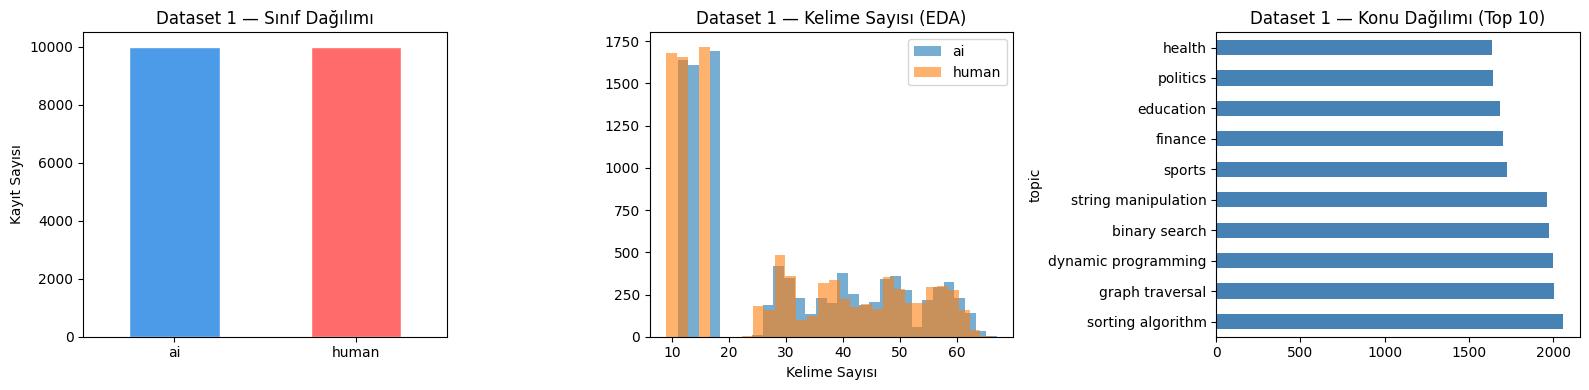

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sınıf dağılımı
df1_raw['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#4C9BE8','#FF6B6B'], edgecolor='white')
axes[0].set_title('Dataset 1 — Sınıf Dağılımı', fontsize=12)
axes[0].set_xlabel(''); axes[0].set_ylabel('Kayıt Sayısı')
axes[0].tick_params(axis='x', rotation=0)

# Kelime sayısı dağılımı (EDA amaçlı, özellik değil)
df1_raw['_wc'] = df1_raw['content'].apply(lambda x: len(str(x).split()))
for lbl, grp in df1_raw.groupby('label'):
    axes[1].hist(grp['_wc'], bins=30, alpha=0.6, label=lbl)
axes[1].set_title('Dataset 1 — Kelime Sayısı (EDA)', fontsize=12)
axes[1].set_xlabel('Kelime Sayısı'); axes[1].legend()

# Konu dağılımı
df1_raw['topic'].value_counts().head(10).plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Dataset 1 — Konu Dağılımı (Top 10)', fontsize=12)

plt.tight_layout(); plt.show()

## 1.4 Metin İçi Sızıntı Tespiti

In [27]:
# Doğrudan etiket ifadesi içeren satırları tespit et
df1_raw['has_leak'] = df1_raw['content'].apply(has_label_leak)

leak_by_label = df1_raw.groupby('label')['has_leak'].sum()
print("Label bazında sızıntılı satır sayısı:")
print(leak_by_label)
print(f"\nToplam sızıntılı: {df1_raw['has_leak'].sum()} / {len(df1_raw)}")

print("\n--- Sızıntılı içerik örnekleri (ilk 5) ---")
for i, (_, row) in enumerate(df1_raw[df1_raw['has_leak']].head(5).iterrows()):
    print(f"\n[{i+1}] label={row['label']}")
    print(row['content'][:300])

Label bazında sızıntılı satır sayısı:
label
ai       10004
human        0
Name: has_leak, dtype: int64

Toplam sızıntılı: 10004 / 20000

--- Sızıntılı içerik örnekleri (ilk 5) ---

[1] label=ai
Experts recommend focusing on health to improve overall outcomes. health has become increasingly important in today's world. Recent studies show that health can have significant impact on society. (AI-generated)

[2] label=ai
The development of finance technologies has accelerated over the past decade. Experts recommend focusing on finance to improve overall outcomes. Experts recommend focusing on finance to improve overall outcomes. Understanding finance is crucial for professionals in this field. Experts recommend focu

[3] label=ai
Recent studies show that finance can have significant impact on society. Recent studies show that finance can have significant impact on society. finance has become increasingly important in today's world. The development of finance technologies has accelerated ove

## 1.5 Dataset Cleaning

Her filtre adımında kaç AI / kaç Human kaydın düştüğü ayrı ayrı raporlanır.

**Filtre sırası:**
1. `word_count >= 50` — kısa/kalıplaşmış metinleri ele
2. Metin içindeki sızıntılı ifadeyi `clean_text()` ile **sil** (satırı kaldırma)
3. Temizlik sonrası `word_count >= 20` — ifade silindikten sonra anlamsız kısa kalan metinleri ele
4. Leakage taşıyan diğer tüm sütunları düşür, yalnızca `content_clean` ve `label` sakla

In [28]:
def filtre_raporu(df_once, df_sonra, label_col, adim_adi):
    """İki DataFrame arasındaki farkı label bazında raporlar."""
    once  = df_once[label_col].value_counts().sort_index()
    sonra = df_sonra[label_col].value_counts().sort_index()
    dusen = once.subtract(sonra, fill_value=0)
    print(f"  ── {adim_adi}")
    print(f"     {'Sınıf':<10} {'Önce':>7} {'Sonra':>7} {'Düşen':>7}")
    print(f"     {'-'*33}")
    for lbl in sorted(set(once.index) | set(sonra.index)):
        o = int(once.get(lbl, 0))
        s = int(sonra.get(lbl, 0))
        d = o - s
        isim = 'AI' if lbl == 1 else 'Human'
        flag = ' ⚠️' if d > 0 and lbl == 0 else ''  # human kayıplarını işaretle
        print(f"     {isim:<10} {o:>7} {s:>7} {d:>7}{flag}")
    print(f"     {'TOPLAM':<10} {int(once.sum()):>7} {int(sonra.sum()):>7} {int(dusen.sum()):>7}")
    print()

# Label → sayısal (rapor için önce dönüştür)
df1_raw['label_num'] = df1_raw['label'].map({'ai': 1, 'human': 0})

print("=" * 50)
print("  DS1 — Adım Adım Filtre Raporu")
print("=" * 50)
print(f"  Başlangıç: {len(df1_raw)} kayıt  "
      f"(AI: {(df1_raw['label_num']==1).sum()}, "
      f"Human: {(df1_raw['label_num']==0).sum()})")
print()

# ── Adım 1: word_count >= 50 ──────────────────────────────────────────────────
df1_raw['_wc_raw'] = df1_raw['content'].apply(lambda x: len(str(x).split()))
df1_step1 = df1_raw[df1_raw['_wc_raw'] >= 50].copy()
filtre_raporu(df1_raw, df1_step1, 'label_num', "Adım 1 — word_count >= 50 filtresi")

# ── Adım 2: sızıntılı ifadeyi metinden sil ────────────────────────────────────
# (satır kaldırılmıyor, sadece ifade temizleniyor)
df1_step2 = df1_step1.copy()
df1_step2['content_clean'] = df1_step2['content'].apply(clean_text)

# Kaç satırda ifade silindi?
leak_once  = df1_step1['content'].apply(has_label_leak)
leak_sonra = df1_step2['content_clean'].apply(has_label_leak)
print(f"  ── Adım 2 — Sızıntılı ifade metinden silindi (satır kaldırılmadı)")
print(f"     Silme öncesi sızıntılı satır : {leak_once.sum()}")
print(f"     Silme sonrası sızıntılı satır: {leak_sonra.sum()}")
print(f"     Label dağılımı değişmedi     : {df1_step2['label_num'].value_counts().to_dict()}")
print()

# ── Adım 3: temizlik sonrası word_count >= 20 ─────────────────────────────────
df1_step2['_wc_clean'] = df1_step2['content_clean'].apply(lambda x: len(str(x).split()))
df1_step3 = df1_step2[df1_step2['_wc_clean'] >= 20].copy()
filtre_raporu(df1_step2, df1_step3, 'label_num', "Adım 3 — word_count >= 20 (temizlik sonrası)")

# ── Final ─────────────────────────────────────────────────────────────────────
df1 = df1_step3[['content_clean', 'label_num']].rename(columns={'label_num': 'label'})

print("=" * 50)
print(f"  SONUÇ: {len(df1)} kayıt")
ai_n    = (df1['label']==1).sum()
human_n = (df1['label']==0).sum()
print(f"  AI   : {ai_n}  ({ai_n/len(df1)*100:.1f}%)")
print(f"  Human: {human_n}  ({human_n/len(df1)*100:.1f}%)")

# Sınıf dengesi uyarısı
ratio = min(ai_n, human_n) / max(ai_n, human_n)
if ratio < 0.7:
    print(f"\n  ⚠️  Sınıf dengesizliği: oran = {ratio:.2f}  (0.7 altı dengesiz)")
    print(f"     Bu durum modeli baskın sınıfa yönlendirebilir.")
else:
    print(f"\n  ✅ Sınıf dengesi kabul edilebilir: oran = {ratio:.2f}")

assert df1['label'].nunique() == 2, "HATA: Bir sınıf tamamen silindi!"
print("  ✅ Her iki sınıf mevcut.")

  DS1 — Adım Adım Filtre Raporu
  Başlangıç: 20000 kayıt  (AI: 10004, Human: 9996)

  ── Adım 1 — word_count >= 50 filtresi
     Sınıf         Önce   Sonra   Düşen
     ---------------------------------
     Human         9996    1607    8389 ⚠️
     AI           10004    1749    8255
     TOPLAM       20000    3356   16644

  ── Adım 2 — Sızıntılı ifade metinden silindi (satır kaldırılmadı)
     Silme öncesi sızıntılı satır : 1749
     Silme sonrası sızıntılı satır: 0
     Label dağılımı değişmedi     : {1: 1749, 0: 1607}

  ── Adım 3 — word_count >= 20 (temizlik sonrası)
     Sınıf         Önce   Sonra   Düşen
     ---------------------------------
     Human         1607    1607       0
     AI            1749    1749       0
     TOPLAM        3356    3356       0

  SONUÇ: 3356 kayıt
  AI   : 1749  (52.1%)
  Human: 1607  (47.9%)

  ✅ Sınıf dengesi kabul edilebilir: oran = 0.92
  ✅ Her iki sınıf mevcut.


## 1.6 Train-Test Split

In [29]:
X1_train_text, X1_test_text, y1_train, y1_test = train_test_split(
    df1['content_clean'], df1['label'],
    test_size=0.2, random_state=42, stratify=df1['label'])

print(f"Eğitim : {len(X1_train_text)} kayıt | Test : {len(X1_test_text)} kayıt")
print(f"Train sınıf dağılımı:\n{y1_train.value_counts()}")
print(f"Test  sınıf dağılımı:\n{y1_test.value_counts()}")

Eğitim : 2684 kayıt | Test : 672 kayıt
Train sınıf dağılımı:
label
1    1399
0    1285
Name: count, dtype: int64
Test  sınıf dağılımı:
label
1    350
0    322
Name: count, dtype: int64


In [30]:
# TF-IDF — sadece train üzerinde fit
# max_df=0.99 (önceki 0.95 DS1'deki yüksek frekanslı ama anlamlı kelimeleri de eliyordu)
tfidf_1 = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=15000,
    sublinear_tf=True,
    min_df=2,
    max_df=0.99,   # ← gevşetildi
)
X1_train_tf = tfidf_1.fit_transform(X1_train_text)
X1_test_tf  = tfidf_1.transform(X1_test_text)

print(f"Vocabulary boyutu : {len(tfidf_1.vocabulary_)}")
print(f"Eğitim matrisi    : {X1_train_tf.shape}")
print(f"Test matrisi      : {X1_test_tf.shape}")

# Vocabulary sağlık kontrolü — 183 gibiyse DS1 hâlâ sorunlu demektir
vocab_size = len(tfidf_1.vocabulary_)
if vocab_size < 500:
    print(f"\n⚠️  UYARI: Vocabulary çok küçük ({vocab_size}). DS1 metinleri hâlâ çok kalıplaşmış olabilir.")
elif vocab_size < 2000:
    print(f"\n🟡 Vocabulary orta düzeyde ({vocab_size}). Model sınırlı sinyal öğrenecektir.")
else:
    print(f"\n✅ Vocabulary yeterli ({vocab_size}).")

Vocabulary boyutu : 183
Eğitim matrisi    : (2684, 183)
Test matrisi      : (672, 183)

⚠️  UYARI: Vocabulary çok küçük (183). DS1 metinleri hâlâ çok kalıplaşmış olabilir.


---
# Dataset 2: DAIGT V2 Train Dataset
**Kaynak:** [Kaggle – DAIGT V2](https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset)

## 2.1 Veriyi İndirme ve Yükleme

In [31]:
od.download("https://www.kaggle.com/datasets/thedrcat/daigt-v2-train-dataset")

df2_raw = pd.read_csv('./daigt-v2-train-dataset/train_v2_drcat_02.csv')

print(f"Boyut   : {df2_raw.shape}")
print(f"Sütunlar: {df2_raw.columns.tolist()}")
print(f"\nEtiket dağılımı (0=Human, 1=AI):\n{df2_raw['label'].value_counts()}")
df2_raw.head(3)

Skipping, found downloaded files in "./daigt-v2-train-dataset" (use force=True to force download)
Boyut   : (44868, 5)
Sütunlar: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven']

Etiket dağılımı (0=Human, 1=AI):
label
0    27371
1    17497
Name: count, dtype: int64


,text,label,prompt_name,source,RDizzl3_seven
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False


## 2.2 Sütun Leakage Denetimi

In [32]:
leaky_cols_2 = audit_columns(df2_raw, label_col='label',
                              text_col='text', dataset_name='Dataset 2')

# source sütununun unique değerlerine bak
print("\n--- 'source' sütunu unique değerleri ---")
print(df2_raw['source'].value_counts().head(20))

print("\n--- 'prompt_name' sütunu unique değerleri ---")
print(df2_raw['prompt_name'].value_counts().head(20))

print("\n--- 'RDizzl3_seven' sütunu ---")
print(df2_raw['RDizzl3_seven'].value_counts())


  SÜTUN LEAKAGE DENETİMİ — Dataset 2
  [🟡 Şüpheli] prompt_name                    | kategorik | unique=  15 | label_bias=0.56 | null_corr=+nan
  [🔴 LEAKY] source                         | kategorik | unique=  17 | label_bias=1.00 | null_corr=+nan
  [🟡 Şüpheli] RDizzl3_seven                  | sayısal | corr=-0.163 | missing=0

  ⚠️  Leaky/Şüpheli sütunlar: ['prompt_name', 'source', 'RDizzl3_seven']

--- 'source' sütunu unique değerleri ---
source
persuade_corpus                       25996
mistral7binstruct_v2                   2421
chat_gpt_moth                          2421
llama2_chat                            2421
mistral7binstruct_v1                   2421
kingki19_palm                          1384
train_essays                           1378
llama_70b_v1                           1172
falcon_180b_v1                         1055
darragh_claude_v6                      1000
darragh_claude_v7                      1000
radek_500                               500
NousResearch/Llama-2

## 2.3 Keşifsel Veri Analizi (EDA)

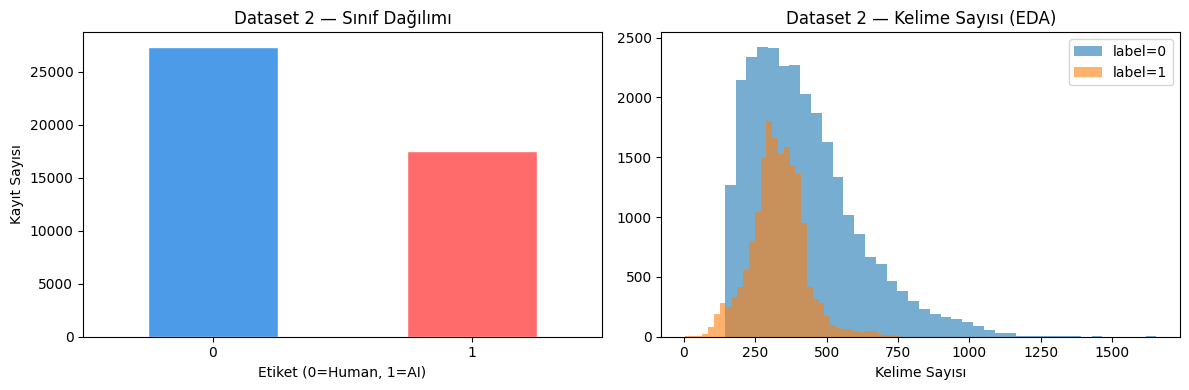

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df2_raw['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#4C9BE8','#FF6B6B'], edgecolor='white')
axes[0].set_title('Dataset 2 — Sınıf Dağılımı', fontsize=12)
axes[0].set_xlabel('Etiket (0=Human, 1=AI)'); axes[0].set_ylabel('Kayıt Sayısı')
axes[0].tick_params(axis='x', rotation=0)

df2_raw['_wc'] = df2_raw['text'].apply(lambda x: len(str(x).split()))
for lbl, grp in df2_raw.groupby('label'):
    axes[1].hist(grp['_wc'], bins=40, alpha=0.6, label=f'label={lbl}')
axes[1].set_title('Dataset 2 — Kelime Sayısı (EDA)', fontsize=12)
axes[1].set_xlabel('Kelime Sayısı'); axes[1].legend()

plt.tight_layout(); plt.show()

## 2.4 Metin İçi Sızıntı Tespiti

In [34]:
df2_raw['has_leak'] = df2_raw['text'].apply(has_label_leak)

leak_by_label_2 = df2_raw.groupby('label')['has_leak'].sum()
print("Label bazında sızıntılı satır sayısı:")
print(leak_by_label_2)
print(f"\nToplam sızıntılı: {df2_raw['has_leak'].sum()} / {len(df2_raw)}")

print("\n--- Sızıntılı içerik örnekleri (ilk 5) ---")
for i, (_, row) in enumerate(df2_raw[df2_raw['has_leak']].head(5).iterrows()):
    print(f"\n[{i+1}] label={row['label']}")
    print(row['text'][:300])

Label bazında sızıntılı satır sayısı:
label
0    5
1    9
Name: has_leak, dtype: int64

Toplam sızıntılı: 14 / 44868

--- Sızıntılı içerik örnekleri (ilk 5) ---

[1] label=0
I was discussing the face with a friend who thinks it's created by aliens and I think it was not created by aliens. These are my reasons why I think it is a natural landform. NASA and other scientist said it was a natural landform. The face was equivalent of a butte or mesa says NASA.

The face is e

[2] label=0
The Face, a discovery on Mars. It was dicovered on 1976 and it was complicated to predict what it actually was. It was explored when NASA's Viking 1 was snapping photos of possible land places for the ship Viking 2.

When it was revealed to be a natural landform, not everyone was happy with it. The 

[3] label=0
The Face on Mars is a popular pop icon dating back to 1976 when it was first dicoverd. This face-like landmark has even sparked the minds of conspiracy theorists into believing this is a bona fide s

## 2.5 Dataset Cleaning

**Not:** `source` sütununun leakage denetiminde yüksek bias göstermesi beklenir
(AI satırlarında model adı, human satırlarında yazar adı gibi değerler taşır).
Bu sütun zaten özellik olarak kullanılmıyor — ham metin üzerinden gidiyoruz.

In [35]:
df2 = df2_raw.copy()

# Sızıntılı ifadeyi metinden sil (satır kaldırma yok)
df2['content_clean'] = df2['text'].apply(clean_text)

# Sadece gerekli sütunlar
df2 = df2[['content_clean', 'label']]

print(f"Temizlik sonrası: {len(df2)} kayıt")
print(f"Sınıf dağılımı:\n{df2['label'].value_counts()}")

assert df2['label'].nunique() == 2, "HATA: Bir sınıf tamamen silindi!"
print("\n✅ Her iki sınıf mevcut.")

Temizlik sonrası: 44868 kayıt
Sınıf dağılımı:
label
0    27371
1    17497
Name: count, dtype: int64

✅ Her iki sınıf mevcut.


## 2.6 Train-Test Split

In [36]:
X2_train_text, X2_test_text, y2_train, y2_test = train_test_split(
    df2['content_clean'], df2['label'],
    test_size=0.2, random_state=42, stratify=df2['label'])

print(f"Eğitim : {len(X2_train_text)} kayıt | Test : {len(X2_test_text)} kayıt")
print(f"Train sınıf dağılımı:\n{y2_train.value_counts()}")
print(f"Test  sınıf dağılımı:\n{y2_test.value_counts()}")

Eğitim : 35894 kayıt | Test : 8974 kayıt
Train sınıf dağılımı:
label
0    21897
1    13997
Name: count, dtype: int64
Test  sınıf dağılımı:
label
0    5474
1    3500
Name: count, dtype: int64


In [37]:
tfidf_2 = make_tfidf(min_df=2, max_features=15000)
X2_train_tf = tfidf_2.fit_transform(X2_train_text)
X2_test_tf  = tfidf_2.transform(X2_test_text)

print(f"Vocabulary boyutu : {len(tfidf_2.vocabulary_)}")
print(f"Eğitim matrisi    : {X2_train_tf.shape}")
print(f"Test matrisi      : {X2_test_tf.shape}")

Vocabulary boyutu : 15000
Eğitim matrisi    : (35894, 15000)
Test matrisi      : (8974, 15000)


---
# Model Eğitimi ve Değerlendirme

Her veri seti kombinasyonu için **3 farklı algoritma** ayrı ayrı eğitilir ve test edilir:

| # | Algoritma | Açıklama |
|---|-----------|----------|
| 1 | **Multinomial Naive Bayes (MNB)** | TF-IDF frekanslarını olasılıksal olarak modelleyen, hızlı ve yorumlanabilir baseline |
| 2 | **XGBoost + TF-IDF** | Gradient boosting ile seyrek TF-IDF vektörlerini sınıflandırır |
| 3 | **Transformer (DistilBERT)** | Bağlamsal kelime temsilleri; fine-tuning ile metin sınıflandırma |

**Eğitim senaryoları:**
- **A** → DS1 train: DS1 test, DS2 test (cross-domain)
- **B** → DS2 train: DS2 test, DS1 test (cross-domain)  
- **C** → DS1+DS2 train: DS1+DS2 karışık test

## Ortak Yardımcı Fonksiyonlar

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, vectorizer, X_text, y_true, label="", is_transformer=False):
    """
    Hem klasik (MNB/XGB) hem transformer modeller için ortak değerlendirme.
    is_transformer=True ise vectorizer kullanılmaz, model doğrudan metin alır.
    """
    if is_transformer:
        y_pred = model.predict(list(X_text))
        y_prob = model.predict_proba(list(X_text))
    else:
        X_tf   = vectorizer.transform(X_text)
        y_pred = model.predict(X_tf)
        y_prob = model.predict_proba(X_tf) if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*58}")
    print(f"  {label}")
    print(f"  Accuracy: %{acc*100:.2f}")
    print(f"{'='*58}")
    print(classification_report(
        y_true, y_pred,
        labels=[0, 1],
        target_names=['Human (0)', 'AI (1)'],
        zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human','AI'], yticklabels=['Human','AI'])
    plt.title(label, fontsize=9)
    plt.ylabel('Gerçek'); plt.xlabel('Tahmin')
    plt.tight_layout(); plt.show()
    return acc

# Sonuçları toplamak için global dict
all_results = {}
print("Yardımcı fonksiyonlar hazır.")

Yardımcı fonksiyonlar hazır.


---
# 1. Multinomial Naive Bayes (MNB)

TF-IDF vektörlerini Bayes teoremi ile sınıflandırır. Her kelimenin sınıf koşullu
olasılığını öğrenir. Hızlı, yorumlanabilir ve sparse vektörlerle iyi çalışır.

> **Not:** MNB negatif TF-IDF değeri kabul etmez. `sublinear_tf=False` kullanılır.

## 1.1 MNB — TF-IDF Hazırlığı

## Birleşik Veri Seti (DS1 + DS2)

Tüm algoritmaların Model C eğitiminde kullanılacak birleşik train/test setleri burada hazırlanır.

In [39]:
# ── Birleşik eğitim ve test setleri ─────────────────────────────────────────
# MNB, XGBoost ve Transformer bölümlerinin tamamında kullanılacak
X_comb_train = pd.concat([X1_train_text, X2_train_text], ignore_index=True)
y_comb_train = pd.concat([y1_train,      y2_train],      ignore_index=True)

X_comb_test  = pd.concat([X1_test_text,  X2_test_text],  ignore_index=True)
y_comb_test  = pd.concat([y1_test,        y2_test],       ignore_index=True)

print(f"Birleşik eğitim : {len(X_comb_train)} kayıt  "
      f"(AI: {(y_comb_train==1).sum()}, Human: {(y_comb_train==0).sum()})")
print(f"Birleşik test   : {len(X_comb_test)} kayıt  "
      f"(AI: {(y_comb_test==1).sum()}, Human: {(y_comb_test==0).sum()})")

Birleşik eğitim : 38578 kayıt  (AI: 15396, Human: 23182)
Birleşik test   : 9646 kayıt  (AI: 3850, Human: 5796)


In [40]:
# MNB negatif değer kabul etmez → sublinear_tf=False, normalize=True
from sklearn.preprocessing import normalize

def make_tfidf_mnb(train_text, test_texts, max_features=15000):
    """MNB için TF-IDF: sublinear_tf=False, L1 normalize."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    vec = TfidfVectorizer(ngram_range=(1,2), max_features=max_features,
                          sublinear_tf=False, min_df=2, max_df=0.99)
    X_tr = normalize(vec.fit_transform(train_text), norm='l1')
    X_tests = [normalize(vec.transform(t), norm='l1') for t in test_texts]
    return vec, X_tr, X_tests

# DS1 train
mnb_vec_1, X1_mnb_train, [X1_mnb_test, X2_mnb_test_via1] = make_tfidf_mnb(
    X1_train_text, [X1_test_text, X2_test_text])

# DS2 train
mnb_vec_2, X2_mnb_train, [X2_mnb_test, X1_mnb_test_via2] = make_tfidf_mnb(
    X2_train_text, [X2_test_text, X1_test_text])

# Combined train
mnb_vec_C, XC_mnb_train, [XC_mnb_test] = make_tfidf_mnb(
    X_comb_train, [X_comb_test], max_features=20000)

print("MNB TF-IDF matrisleri hazır.")
print(f"  DS1 vocab : {len(mnb_vec_1.vocabulary_)}")
print(f"  DS2 vocab : {len(mnb_vec_2.vocabulary_)}")
print(f"  Comb vocab: {len(mnb_vec_C.vocabulary_)}")

MNB TF-IDF matrisleri hazır.
  DS1 vocab : 183
  DS2 vocab : 15000
  Comb vocab: 20000


## 1.2 MNB — Model A (DS1 Eğitim)

In [41]:
mnb_A = MultinomialNB(alpha=0.1)
mnb_A.fit(X1_mnb_train, y1_train)
print("MNB Model A eğitildi.")

MNB Model A eğitildi.


### MNB A → DS1 Test


  MNB-A | Train:DS1 → Test:DS1
  Accuracy: %52.08
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00       322
          AI       0.52      1.00      0.68       350

    accuracy                           0.52       672
   macro avg       0.26      0.50      0.34       672
weighted avg       0.27      0.52      0.36       672



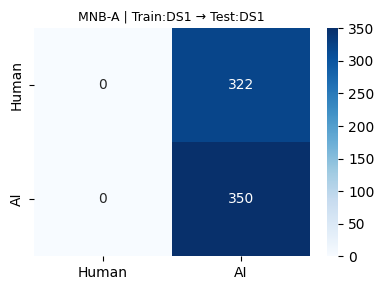

In [42]:
y_pred = mnb_A.predict(X1_mnb_test)
acc = accuracy_score(y1_test, y_pred)
print(f"\n{'='*58}")
print(f"  MNB-A | Train:DS1 → Test:DS1")
print(f"  Accuracy: %{acc*100:.2f}")
print(f"{'='*58}")
print(classification_report(y1_test, y_pred, labels=[0,1],
      target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y1_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("MNB-A | Train:DS1 → Test:DS1", fontsize=9)
plt.tight_layout(); plt.show()
all_results['MNB-A→DS1'] = acc

### MNB A → DS2 Test (Cross-Domain)


  MNB-A | Train:DS1 → Test:DS2 (cross-domain)
  Accuracy: %39.00
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00      5474
          AI       0.39      1.00      0.56      3500

    accuracy                           0.39      8974
   macro avg       0.20      0.50      0.28      8974
weighted avg       0.15      0.39      0.22      8974



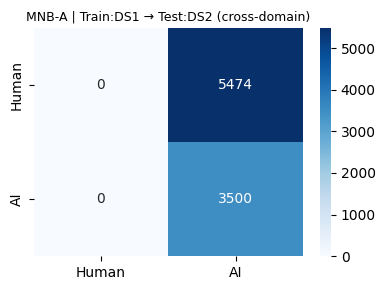

In [43]:
y_pred = mnb_A.predict(X2_mnb_test_via1)
acc = accuracy_score(y2_test, y_pred)
print(f"\n{'='*58}")
print(f"  MNB-A | Train:DS1 → Test:DS2 (cross-domain)")
print(f"  Accuracy: %{acc*100:.2f}")
print(f"{'='*58}")
print(classification_report(y2_test, y_pred, labels=[0,1],
      target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y2_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("MNB-A | Train:DS1 → Test:DS2 (cross-domain)", fontsize=9)
plt.tight_layout(); plt.show()
all_results['MNB-A→DS2'] = acc

## 1.3 MNB — Model B (DS2 Eğitim)

In [44]:
mnb_B = MultinomialNB(alpha=0.1)
mnb_B.fit(X2_mnb_train, y2_train)
print("MNB Model B eğitildi.")

MNB Model B eğitildi.


### MNB B → DS2 Test


  MNB-B | Train:DS2 → Test:DS2
  Accuracy: %88.73
              precision    recall  f1-score   support

       Human       0.84      1.00      0.92      5474
          AI       1.00      0.71      0.83      3500

    accuracy                           0.89      8974
   macro avg       0.92      0.86      0.87      8974
weighted avg       0.90      0.89      0.88      8974



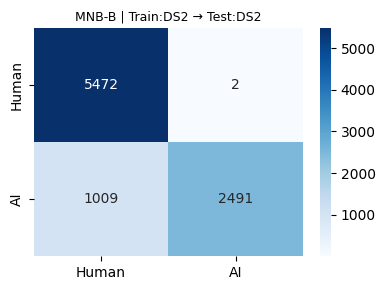

In [45]:
y_pred = mnb_B.predict(X2_mnb_test)
acc = accuracy_score(y2_test, y_pred)
print(f"\n{'='*58}")
print(f"  MNB-B | Train:DS2 → Test:DS2")
print(f"  Accuracy: %{acc*100:.2f}")
print(f"{'='*58}")
print(classification_report(y2_test, y_pred, labels=[0,1],
      target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y2_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("MNB-B | Train:DS2 → Test:DS2", fontsize=9)
plt.tight_layout(); plt.show()
all_results['MNB-B→DS2'] = acc

### MNB B → DS1 Test (Cross-Domain)


  MNB-B | Train:DS2 → Test:DS1 (cross-domain)
  Accuracy: %51.79
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00       322
          AI       0.52      0.99      0.68       350

    accuracy                           0.52       672
   macro avg       0.26      0.50      0.34       672
weighted avg       0.27      0.52      0.36       672



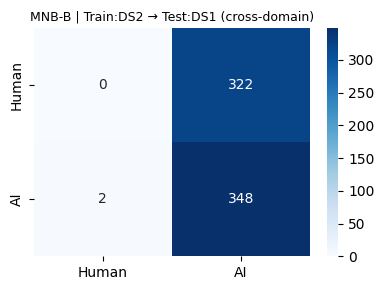

In [46]:
y_pred = mnb_B.predict(X1_mnb_test_via2)
acc = accuracy_score(y1_test, y_pred)
print(f"\n{'='*58}")
print(f"  MNB-B | Train:DS2 → Test:DS1 (cross-domain)")
print(f"  Accuracy: %{acc*100:.2f}")
print(f"{'='*58}")
print(classification_report(y1_test, y_pred, labels=[0,1],
      target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y1_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("MNB-B | Train:DS2 → Test:DS1 (cross-domain)", fontsize=9)
plt.tight_layout(); plt.show()
all_results['MNB-B→DS1'] = acc

## 1.4 MNB — Model C (DS1+DS2 Birleşik)

In [47]:
mnb_C = MultinomialNB(alpha=0.1)
mnb_C.fit(XC_mnb_train, y_comb_train)
print("MNB Model C eğitildi.")

MNB Model C eğitildi.


### MNB C → DS1+DS2 Karışık Test


  MNB-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık
  Accuracy: %85.93
              precision    recall  f1-score   support

       Human       0.84      0.95      0.89      5796
          AI       0.91      0.72      0.80      3850

    accuracy                           0.86      9646
   macro avg       0.87      0.84      0.85      9646
weighted avg       0.87      0.86      0.86      9646



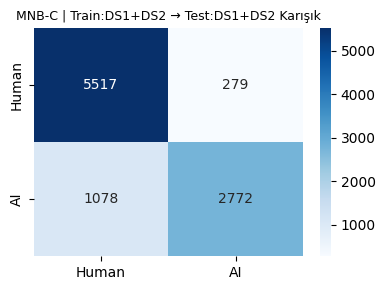

In [48]:
y_pred = mnb_C.predict(XC_mnb_test)
acc = accuracy_score(y_comb_test, y_pred)
print(f"\n{'='*58}")
print(f"  MNB-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık")
print(f"  Accuracy: %{acc*100:.2f}")
print(f"{'='*58}")
print(classification_report(y_comb_test, y_pred, labels=[0,1],
      target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y_comb_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("MNB-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık", fontsize=9)
plt.tight_layout(); plt.show()
all_results['MNB-C→DS1+DS2'] = acc

---
# 2. XGBoost + TF-IDF

Gradient boosting ile karar ağaçlarını sıralı olarak birbirine ekler.
Her ağaç öncekinin hatasını düzeltmeye çalışır. Seyrek TF-IDF vektörleriyle
iyi çalışır; `tree_method='hist'` ile büyük veri setlerinde hızlıdır.

## 2.1 XGBoost — TF-IDF Hazırlığı

In [49]:
from xgboost import XGBClassifier

# XGBoost sublinear_tf=True (log normalizasyon) ile daha iyi çalışır
tfidf_1 = make_tfidf(min_df=2, max_features=15000)
X1_xgb_train = tfidf_1.fit_transform(X1_train_text)
X1_xgb_test  = tfidf_1.transform(X1_test_text)
X2_xgb_test_via1 = tfidf_1.transform(X2_test_text)

tfidf_2 = make_tfidf(min_df=2, max_features=15000)
X2_xgb_train = tfidf_2.fit_transform(X2_train_text)
X2_xgb_test  = tfidf_2.transform(X2_test_text)
X1_xgb_test_via2 = tfidf_2.transform(X1_test_text)

tfidf_C = make_tfidf(min_df=2, max_features=20000)
XC_xgb_train = tfidf_C.fit_transform(X_comb_train)
XC_xgb_test  = tfidf_C.transform(X_comb_test)

print("XGBoost TF-IDF matrisleri hazır.")
print(f"  DS1 vocab : {len(tfidf_1.vocabulary_)}")
print(f"  DS2 vocab : {len(tfidf_2.vocabulary_)}")
print(f"  Comb vocab: {len(tfidf_C.vocabulary_)}")

XGBoost TF-IDF matrisleri hazır.
  DS1 vocab : 183
  DS2 vocab : 15000
  Comb vocab: 20000


## 2.2 XGBoost — Model A (DS1 Eğitim)

In [50]:
xgb_A = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                       tree_method='hist', random_state=42, eval_metric='logloss')
xgb_A.fit(X1_xgb_train, y1_train)
print("XGBoost Model A eğitildi.")

XGBoost Model A eğitildi.


### XGB A → DS1 Test


  XGB-A | Train:DS1 → Test:DS1
  Accuracy: %50.89
              precision    recall  f1-score   support

       Human       0.49      0.42      0.45       322
          AI       0.53      0.59      0.56       350

    accuracy                           0.51       672
   macro avg       0.51      0.51      0.50       672
weighted avg       0.51      0.51      0.51       672



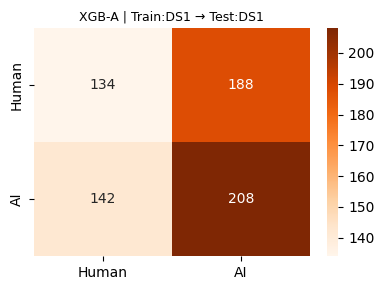

In [51]:
y_pred = xgb_A.predict(X1_xgb_test)
acc = accuracy_score(y1_test, y_pred)
print(f"\n{'='*58}\n  XGB-A | Train:DS1 → Test:DS1\n  Accuracy: %{acc*100:.2f}\n{'='*58}")
print(classification_report(y1_test, y_pred, labels=[0,1], target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y1_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("XGB-A | Train:DS1 → Test:DS1", fontsize=9); plt.tight_layout(); plt.show()
all_results['XGB-A→DS1'] = acc

### XGB A → DS2 Test (Cross-Domain)


  XGB-A | Train:DS1 → Test:DS2 (cross-domain)
  Accuracy: %52.17
              precision    recall  f1-score   support

       Human       0.60      0.66      0.63      5474
          AI       0.37      0.31      0.34      3500

    accuracy                           0.52      8974
   macro avg       0.48      0.48      0.48      8974
weighted avg       0.51      0.52      0.51      8974



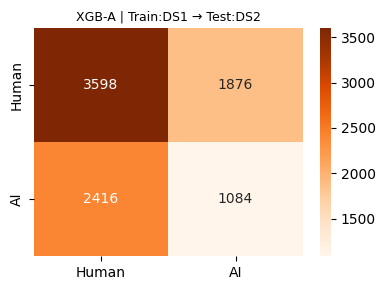

In [52]:
y_pred = xgb_A.predict(X2_xgb_test_via1)
acc = accuracy_score(y2_test, y_pred)
print(f"\n{'='*58}\n  XGB-A | Train:DS1 → Test:DS2 (cross-domain)\n  Accuracy: %{acc*100:.2f}\n{'='*58}")
print(classification_report(y2_test, y_pred, labels=[0,1], target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y2_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("XGB-A | Train:DS1 → Test:DS2", fontsize=9); plt.tight_layout(); plt.show()
all_results['XGB-A→DS2'] = acc

## 2.3 XGBoost — Model B (DS2 Eğitim)

In [53]:
xgb_B = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                       tree_method='hist', random_state=42, eval_metric='logloss')
xgb_B.fit(X2_xgb_train, y2_train)
print("XGBoost Model B eğitildi.")

XGBoost Model B eğitildi.


### XGB B → DS2 Test


  XGB-B | Train:DS2 → Test:DS2
  Accuracy: %99.09
              precision    recall  f1-score   support

       Human       0.99      1.00      0.99      5474
          AI       0.99      0.98      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



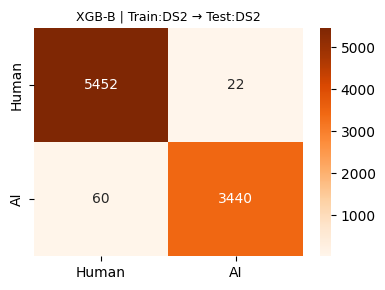

In [54]:
y_pred = xgb_B.predict(X2_xgb_test)
acc = accuracy_score(y2_test, y_pred)
print(f"\n{'='*58}\n  XGB-B | Train:DS2 → Test:DS2\n  Accuracy: %{acc*100:.2f}\n{'='*58}")
print(classification_report(y2_test, y_pred, labels=[0,1], target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y2_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("XGB-B | Train:DS2 → Test:DS2", fontsize=9); plt.tight_layout(); plt.show()
all_results['XGB-B→DS2'] = acc

### XGB B → DS1 Test (Cross-Domain)


  XGB-B | Train:DS2 → Test:DS1 (cross-domain)
  Accuracy: %52.08
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00       322
          AI       0.52      1.00      0.68       350

    accuracy                           0.52       672
   macro avg       0.26      0.50      0.34       672
weighted avg       0.27      0.52      0.36       672



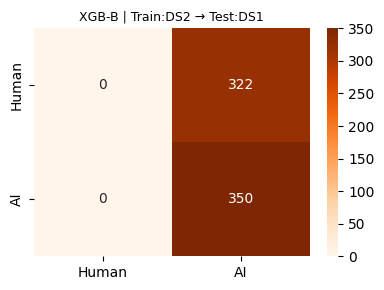

In [55]:
y_pred = xgb_B.predict(X1_xgb_test_via2)
acc = accuracy_score(y1_test, y_pred)
print(f"\n{'='*58}\n  XGB-B | Train:DS2 → Test:DS1 (cross-domain)\n  Accuracy: %{acc*100:.2f}\n{'='*58}")
print(classification_report(y1_test, y_pred, labels=[0,1], target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y1_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("XGB-B | Train:DS2 → Test:DS1", fontsize=9); plt.tight_layout(); plt.show()
all_results['XGB-B→DS1'] = acc

## 2.4 XGBoost — Model C (DS1+DS2 Birleşik)

In [56]:
xgb_C = XGBClassifier(n_estimators=300, learning_rate=0.08, max_depth=5,
                       tree_method='hist', random_state=42, eval_metric='logloss')
xgb_C.fit(XC_xgb_train, y_comb_train)
print("XGBoost Model C eğitildi.")

XGBoost Model C eğitildi.


### XGB C → DS1+DS2 Karışık Test


  XGB-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık
  Accuracy: %95.78
              precision    recall  f1-score   support

       Human       0.97      0.96      0.96      5796
          AI       0.93      0.96      0.95      3850

    accuracy                           0.96      9646
   macro avg       0.95      0.96      0.96      9646
weighted avg       0.96      0.96      0.96      9646



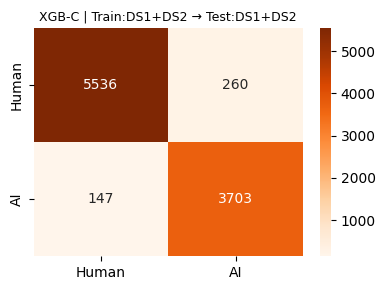

In [57]:
y_pred = xgb_C.predict(XC_xgb_test)
acc = accuracy_score(y_comb_test, y_pred)
print(f"\n{'='*58}\n  XGB-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık\n  Accuracy: %{acc*100:.2f}\n{'='*58}")
print(classification_report(y_comb_test, y_pred, labels=[0,1], target_names=['Human','AI'], zero_division=0))
cm = confusion_matrix(y_comb_test, y_pred, labels=[0,1])
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Human','AI'], yticklabels=['Human','AI'])
plt.title("XGB-C | Train:DS1+DS2 → Test:DS1+DS2", fontsize=9); plt.tight_layout(); plt.show()
all_results['XGB-C→DS1+DS2'] = acc

---
# 3. Transformer — DistilBERT Fine-Tuning

DistilBERT, BERT'in %40 daha küçük ve %60 daha hızlı damıtılmış versiyonudur.
Bağlamsal kelime temsilleri üretir — "bank" kelimesi finans cümlesinde farklı,
nehir cümlesinde farklı encode edilir.

**Fine-tuning stratejisi:** Önceden eğitilmiş DistilBERT'in üstüne
bir sınıflandırma başlığı eklenir, tüm model birlikte ince ayar yapılır.

> **Colab notu:** GPU kullanımı için `Çalışma Zamanı → Çalışma zamanı türünü değiştir → T4 GPU` seçin.

## 3.1 Transformer — Kurulum ve Hazırlık

In [58]:
!pip install transformers datasets -q

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizerFast,
                          DistilBertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Cihaz: {DEVICE}")
if DEVICE == 'cpu':
    print("⚠️  GPU bulunamadı. CPU'da eğitim çok yavaş olabilir.")
    print("   Colab'da: Çalışma Zamanı → Çalışma Zamanı Türünü Değiştir → T4 GPU")

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f"Tokenizer yüklendi: {MODEL_NAME}")

Cihaz: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer yüklendi: distilbert-base-uncased


## 3.2 Dataset Sınıfı ve Yardımcılar

In [59]:
MAX_LEN    = 256   # token limit — uzun metinler kırpılır
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

def train_transformer(train_texts, train_labels, model_name=MODEL_NAME, epochs=EPOCHS):
    """DistilBERT fine-tuning. Eğitilmiş modeli döndürür."""
    dataset  = TextDataset(train_texts, train_labels, tokenizer)
    loader   = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    model = DistilBertForSequenceClassification.from_pretrained(
        model_name, num_labels=2).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps//10,
        num_training_steps=total_steps)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in loader:
            optimizer.zero_grad()
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['labels'].to(DEVICE)
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        print(f"  Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")
    return model

def predict_transformer(model, texts, batch_size=BATCH_SIZE):
    """Transformer modelden tahmin ve olasılık üretir."""
    dataset = TextDataset(texts, [0]*len(texts), tokenizer)
    loader  = DataLoader(dataset, batch_size=batch_size)
    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            preds   = probs.argmax(axis=1)
            all_preds.extend(preds)
            all_probs.extend(probs)
    return all_preds, all_probs

def evaluate_transformer(model, X_text, y_true, label=""):
    """Transformer model değerlendirmesi."""
    y_pred, y_probs = predict_transformer(model, list(X_text))
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*58}\n  {label}\n  Accuracy: %{acc*100:.2f}\n{'='*58}")
    print(classification_report(y_true, y_pred, labels=[0,1],
          target_names=['Human','AI'], zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Human','AI'], yticklabels=['Human','AI'])
    plt.title(label, fontsize=9); plt.tight_layout(); plt.show()
    return acc

print("Transformer yardımcı fonksiyonlar hazır.")

Transformer yardımcı fonksiyonlar hazır.


## 3.3 Transformer — Model A (DS1 Eğitim)

In [60]:
print("Transformer Model A eğitimi başlıyor (DS1 train)...")
bert_A = train_transformer(X1_train_text, y1_train)
print("Model A eğitimi tamamlandı.")

Transformer Model A eğitimi başlıyor (DS1 train)...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Loss: 0.6945
  Epoch 2/3 — Loss: 0.6932
  Epoch 3/3 — Loss: 0.6923
Model A eğitimi tamamlandı.


### Transformer A → DS1 Test


  BERT-A | Train:DS1 → Test:DS1
  Accuracy: %49.70
              precision    recall  f1-score   support

       Human       0.45      0.20      0.28       322
          AI       0.51      0.77      0.61       350

    accuracy                           0.50       672
   macro avg       0.48      0.49      0.45       672
weighted avg       0.48      0.50      0.45       672



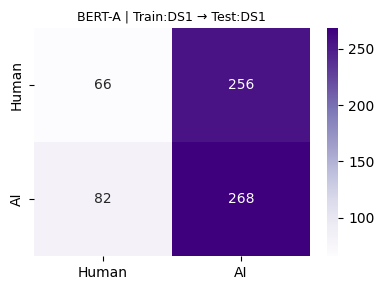

In [61]:
acc = evaluate_transformer(bert_A, X1_test_text, y1_test,
                           label="BERT-A | Train:DS1 → Test:DS1")
all_results['BERT-A→DS1'] = acc

### Transformer A → DS2 Test (Cross-Domain)


  BERT-A | Train:DS1 → Test:DS2 (cross-domain)
  Accuracy: %39.00
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00      5474
          AI       0.39      1.00      0.56      3500

    accuracy                           0.39      8974
   macro avg       0.20      0.50      0.28      8974
weighted avg       0.15      0.39      0.22      8974



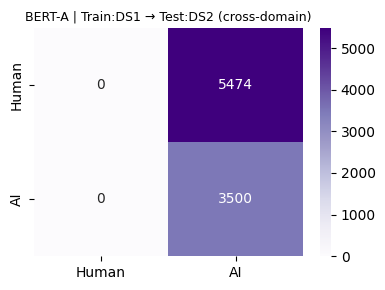

In [62]:
acc = evaluate_transformer(bert_A, X2_test_text, y2_test,
                           label="BERT-A | Train:DS1 → Test:DS2 (cross-domain)")
all_results['BERT-A→DS2'] = acc

## 3.4 Transformer — Model B (DS2 Eğitim)

In [63]:
print("Transformer Model B eğitimi başlıyor (DS2 train)...")
bert_B = train_transformer(X2_train_text, y2_train)
print("Model B eğitimi tamamlandı.")

Transformer Model B eğitimi başlıyor (DS2 train)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Loss: 0.1090
  Epoch 2/3 — Loss: 0.0175
  Epoch 3/3 — Loss: 0.0046
Model B eğitimi tamamlandı.


### Transformer B → DS2 Test


  BERT-B | Train:DS2 → Test:DS2
  Accuracy: %99.13
              precision    recall  f1-score   support

       Human       1.00      0.99      0.99      5474
          AI       0.98      1.00      0.99      3500

    accuracy                           0.99      8974
   macro avg       0.99      0.99      0.99      8974
weighted avg       0.99      0.99      0.99      8974



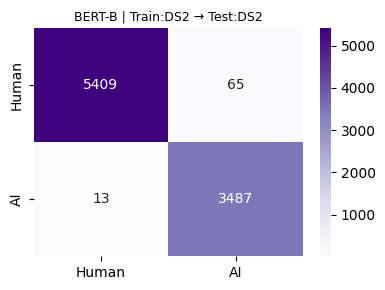

In [64]:
acc = evaluate_transformer(bert_B, X2_test_text, y2_test,
                           label="BERT-B | Train:DS2 → Test:DS2")
all_results['BERT-B→DS2'] = acc

### Transformer B → DS1 Test (Cross-Domain)


  BERT-B | Train:DS2 → Test:DS1 (cross-domain)
  Accuracy: %52.08
              precision    recall  f1-score   support

       Human       0.00      0.00      0.00       322
          AI       0.52      1.00      0.68       350

    accuracy                           0.52       672
   macro avg       0.26      0.50      0.34       672
weighted avg       0.27      0.52      0.36       672



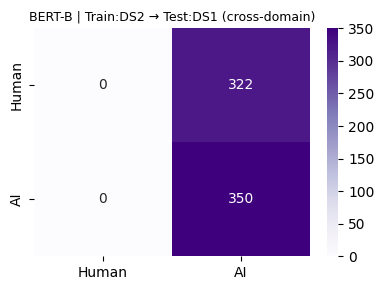

In [65]:
acc = evaluate_transformer(bert_B, X1_test_text, y1_test,
                           label="BERT-B | Train:DS2 → Test:DS1 (cross-domain)")
all_results['BERT-B→DS1'] = acc

## 3.5 Transformer — Model C (DS1+DS2 Birleşik)

In [66]:
print("Transformer Model C eğitimi başlıyor (DS1+DS2 birleşik)...")
bert_C = train_transformer(X_comb_train, y_comb_train)
print("Model C eğitimi tamamlandı.")

Transformer Model C eğitimi başlıyor (DS1+DS2 birleşik)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — Loss: 0.1545
  Epoch 2/3 — Loss: 0.0676
  Epoch 3/3 — Loss: 0.0528
Model C eğitimi tamamlandı.


### Transformer C → DS1+DS2 Karışık Test


  BERT-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık
  Accuracy: %95.89
              precision    recall  f1-score   support

       Human       1.00      0.93      0.96      5796
          AI       0.91      1.00      0.95      3850

    accuracy                           0.96      9646
   macro avg       0.95      0.97      0.96      9646
weighted avg       0.96      0.96      0.96      9646



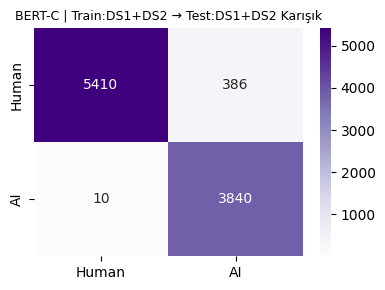

In [67]:
acc = evaluate_transformer(bert_C, X_comb_test, y_comb_test,
                           label="BERT-C | Train:DS1+DS2 → Test:DS1+DS2 Karışık")
all_results['BERT-C→DS1+DS2'] = acc

---
# Genel Karşılaştırma — 3 Algoritma × 5 Senaryo


=== Accuracy (%) — Tüm Model × Senaryo ===
Algoritma   BERT    MNB    XGB
Senaryo                       
A→DS1      49.70  52.08  50.89
A→DS2      39.00  39.00  52.17
B→DS2      99.13  88.73  99.09
B→DS1      52.08  51.79  52.08
C→DS1+DS2  95.89  85.93  95.78


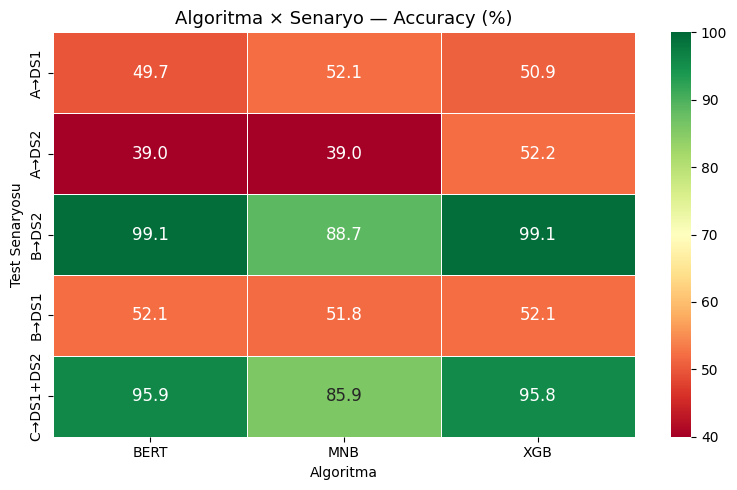

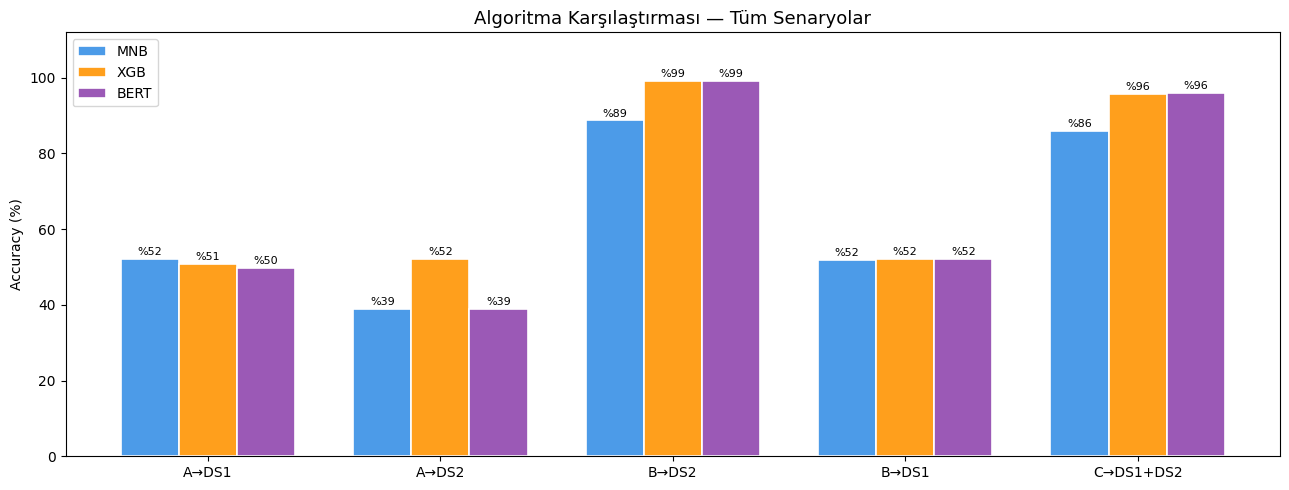

In [68]:
import pandas as pd
import numpy as np

senaryolar = ['A→DS1', 'A→DS2', 'B→DS2', 'B→DS1', 'C→DS1+DS2']
algoritmalar = ['MNB', 'XGB', 'BERT']

rows = []
for algo in algoritmalar:
    for s in senaryolar:
        key = f"{algo}-{s}"
        rows.append({
            'Algoritma' : algo,
            'Senaryo'   : s,
            'Accuracy %': round(all_results.get(key, float('nan')) * 100, 2)
        })

df_results = pd.DataFrame(rows)
pivot = df_results.pivot(index='Senaryo', columns='Algoritma', values='Accuracy %')
pivot = pivot.reindex(senaryolar)

print("\n=== Accuracy (%) — Tüm Model × Senaryo ===")
print(pivot.to_string())

# Isı haritası
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=40, vmax=100, linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Algoritma × Senaryo — Accuracy (%)', fontsize=13)
plt.ylabel('Test Senaryosu'); plt.xlabel('Algoritma')
plt.tight_layout(); plt.show()

# Bar chart — senaryo bazında karşılaştırma
fig, ax = plt.subplots(figsize=(13, 5))
x     = np.arange(len(senaryolar))
width = 0.25
colors = ['#4C9BE8', '#FF9F1C', '#9B59B6']

for i, algo in enumerate(algoritmalar):
    vals = [all_results.get(f"{algo}-{s}", float('nan')) * 100 for s in senaryolar]
    bars = ax.bar(x + i*width, vals, width, label=algo,
                  color=colors[i], edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'%{v:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(senaryolar)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 112)
ax.set_title('Algoritma Karşılaştırması — Tüm Senaryolar', fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

---
# Performance Evaluation

PDF gereksinimi: farklı veri boyutlarında (%10, %50, %100) her algoritma için
**execution time**, **memory usage**, **accuracy/F1/precision/recall** ve
**ROC eğrisi** karşılaştırması.

> Bu bölüm ödevin "Performance Analysis" maddesini karşılar (10 puan).

In [ ]:
import time, tracemalloc
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# ── Ölçüm altyapısı ──────────────────────────────────────────────────────────
def measure(train_fn, predict_fn, X_train, y_train, X_test, y_test):
    """Eğitim + tahmin süresi ve peak memory kullanımını ölçer."""
    # Bellek ölçümü
    tracemalloc.start()
    t0 = time.perf_counter()
    train_fn(X_train, y_train)
    t_train = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = predict_fn(X_test)
    t_infer = time.perf_counter() - t1

    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    return {
        't_train' : t_train,
        't_infer' : t_infer,
        'mem_mb'  : peak / 1024**2,
        'acc' : acc, 'f1': f1, 'prec': prec, 'rec': rec,
        'y_pred': y_pred
    }

print("Ölçüm altyapısı hazır.")

In [ ]:
# ── Farklı veri boyutlarında ölçüm: DS2 üzerinde (en temiz veri seti) ────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import normalize
from sklearn.metrics import f1_score, precision_score, recall_score

FRACS = [0.10, 0.50, 1.00]
perf_rows = []

print("Ölçümler başlıyor (DS2, 3 boyut × 3 algoritma)...")
print("="*60)

for frac in FRACS:
    n = int(len(X2_train_text) * frac)
    X_tr = X2_train_text.iloc[:n]
    y_tr = y2_train.iloc[:n]
    label = f"%{int(frac*100)}"
    print(f"\n── Veri boyutu: {label}  ({n} kayıt) ──")

    # TF-IDF fit (her boyut için ayrı)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vec_xgb = TfidfVectorizer(ngram_range=(1,2), max_features=15000,
                               sublinear_tf=True, min_df=2, max_df=0.99)
    Xtr_xgb = vec_xgb.fit_transform(X_tr)
    Xte_xgb = vec_xgb.transform(X2_test_text)

    vec_mnb = TfidfVectorizer(ngram_range=(1,2), max_features=15000,
                               sublinear_tf=False, min_df=2, max_df=0.99)
    Xtr_mnb = normalize(vec_mnb.fit_transform(X_tr), norm='l1')
    Xte_mnb = normalize(vec_mnb.transform(X2_test_text), norm='l1')

    vec_lr  = TfidfVectorizer(ngram_range=(1,2), max_features=15000,
                               sublinear_tf=True, min_df=2, max_df=0.99)
    Xtr_lr  = vec_lr.fit_transform(X_tr)
    Xte_lr  = vec_lr.transform(X2_test_text)

    configs = [
        ('MNB',  MultinomialNB(alpha=0.1),      Xtr_mnb, Xte_mnb),
        ('XGB',  XGBClassifier(n_estimators=200, learning_rate=0.1,
                               max_depth=5, tree_method='hist',
                               random_state=42, eval_metric='logloss'),
                 Xtr_xgb, Xte_xgb),
        ('LR',   LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                    random_state=42, n_jobs=-1),
                 Xtr_lr, Xte_lr),
    ]

    for algo, model, Xtr, Xte in configs:
        r = measure(
            train_fn   = lambda X, y, m=model: m.fit(X, y),
            predict_fn = lambda X, m=model: m.predict(X),
            X_train=Xtr, y_train=y_tr,
            X_test=Xte,  y_test=y2_test
        )
        perf_rows.append({
            'Algoritma': algo, 'Boyut': label, 'N_train': n,
            'Eğitim (s)': round(r['t_train'],3),
            'Tahmin (s)': round(r['t_infer'],3),
            'Bellek (MB)': round(r['mem_mb'],1),
            'Accuracy':  round(r['acc']*100, 2),
            'F1':        round(r['f1']*100,  2),
            'Precision': round(r['prec']*100,2),
            'Recall':    round(r['rec']*100, 2),
        })
        print(f"  {algo:4s} | Acc:{r['acc']*100:.1f}%  "
              f"F1:{r['f1']*100:.1f}%  "
              f"Train:{r['t_train']:.2f}s  "
              f"Mem:{r['mem_mb']:.1f}MB")

df_perf = pd.DataFrame(perf_rows)
print("\n✅ Ölçümler tamamlandı.")
print(df_perf.to_string(index=False))

In [ ]:
# ── Görsel 1: Execution Time — veri boyutuna göre ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics   = ['Eğitim (s)', 'Tahmin (s)', 'Bellek (MB)']
titles    = ['Eğitim Süresi (sn)', 'Tahmin Süresi (sn)', 'Peak Bellek (MB)']
colors    = {'MNB': '#4C9BE8', 'XGB': '#FF9F1C', 'LR': '#56d364'}

for ax, metric, title in zip(axes, metrics, titles):
    for algo, grp in df_perf.groupby('Algoritma'):
        ax.plot(grp['Boyut'], grp[metric], marker='o', linewidth=2,
                label=algo, color=colors[algo])
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Veri Boyutu')
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Scalability Analizi — DS2 üzerinde %10 / %50 / %100', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Görsel 2: Accuracy & F1 karşılaştırması ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric in zip(axes, ['Accuracy', 'F1']):
    x      = range(len(FRACS))
    width  = 0.25
    labels = [f'%{int(f*100)}' for f in FRACS]

    for i, (algo, color) in enumerate(colors.items()):
        vals = df_perf[df_perf['Algoritma']==algo][metric].values
        bars = ax.bar([xi + i*width for xi in x], vals,
                      width, label=algo, color=color, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks([xi+width for xi in x])
    ax.set_xticklabels(labels)
    ax.set_ylabel(f'{metric} (%)')
    ax.set_title(f'{metric} — Veri Boyutuna Göre')
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Performans Analizi — DS2', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── Görsel 3: ROC Eğrileri (%100 veri, DS2) ──────────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

roc_configs = [
    ('MNB',  mnb_B,  mnb_vec_2,  'mnb'),
    ('XGB',  xgb_B,  tfidf_2,    'xgb'),
    ('BERT', bert_B, None,       'bert'),
]

for algo, model, vec, mtype in roc_configs:
    if mtype == 'bert':
        _, probs = predict_transformer(model, list(X2_test_text))
        y_score = np.array(probs)[:, 1]
    elif mtype == 'mnb':
        from sklearn.preprocessing import normalize
        Xt = normalize(vec.transform(X2_test_text), norm='l1')
        y_score = model.predict_proba(Xt)[:, 1]
    else:
        Xt = vec.transform(X2_test_text)
        y_score = model.predict_proba(Xt)[:, 1]

    fpr, tpr, _ = roc_curve(y2_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{algo} (AUC = {roc_auc:.3f})',
            color=list(colors.values())[['MNB','XGB','BERT'].index(algo)])

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Eğrisi — DS2 Test Seti (Model B)', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Görsel 4: Precision / Recall / F1 — tam tablo ────────────────────────────
df_full = df_perf[df_perf['Boyut']=='%100'][
    ['Algoritma','Accuracy','F1','Precision','Recall','Eğitim (s)','Bellek (MB)']
].reset_index(drop=True)

print("\n=== Tam Performans Tablosu (%100 veri, DS2) ===")
print(df_full.to_string(index=False))

# Radar chart
from matplotlib.patches import FancyArrowPatch
cats   = ['Accuracy','F1','Precision','Recall']
N      = len(cats)
angles = [n/float(N)*2*3.14159 for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for _, row in df_full.iterrows():
    vals = [row[c] for c in cats] + [row[cats[0]]]
    ax.plot(angles, vals, linewidth=2, label=row['Algoritma'],
            color=colors.get(row['Algoritma'],'gray'))
    ax.fill(angles, vals, alpha=0.1, color=colors.get(row['Algoritma'],'gray'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('Radar Chart — Algoritma Karşılaştırması', fontsize=12, pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

---
# Model Kaydetme

Tüm eğitilmiş modeller ve vektörizerleri `pickle` ile diske kaydedilir.
Streamlit uygulaması bu dosyaları yükleyerek kernel gerektirmeden çalışır.

In [ ]:
import pickle, os

SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Kaydedilecekler ───────────────────────────────────────────────────────────
objects = {
    # MNB
    'mnb_A': mnb_A,  'mnb_B': mnb_B,  'mnb_C': mnb_C,
    'mnb_vec_1': mnb_vec_1, 'mnb_vec_2': mnb_vec_2, 'mnb_vec_C': mnb_vec_C,
    # XGBoost
    'xgb_A': xgb_A,  'xgb_B': xgb_B,  'xgb_C': xgb_C,
    'tfidf_1': tfidf_1, 'tfidf_2': tfidf_2, 'tfidf_C': tfidf_C,
    # BERT (state_dict olarak)
    'bert_A_state': bert_A.state_dict(),
    'bert_B_state': bert_B.state_dict(),
    'bert_C_state': bert_C.state_dict(),
    # Performance tablosu
    'df_perf': df_perf,
    # all_results özeti
    'all_results': all_results,
    # Veri setleri (test)
    'X1_test_text': X1_test_text, 'y1_test': y1_test,
    'X2_test_text': X2_test_text, 'y2_test': y2_test,
    'X_comb_test' : X_comb_test,  'y_comb_test': y_comb_test,
}

for name, obj in objects.items():
    path = f'{SAVE_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✅ {name:25s} → {size_kb:8.1f} KB")

print(f"\nToplam {len(objects)} nesne kaydedildi → {SAVE_DIR}/")

---
# İnteraktif Test Arayüzü

Model seçip kendi metninizi girerek tahmin alabilirsiniz.
**Her 3 algoritmanın** 3 senaryosu (A/B/C) seçilebilir.

In [69]:
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    print("✅ ipywidgets hazır")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipywidgets', '-q'])
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    print("✅ ipywidgets yüklendi")

✅ ipywidgets hazır


In [70]:
# ── Model haritası: tüm 9 model ──────────────────────────────────────────────
MODEL_MAP = {
    # MNB
    "MNB — Model A (DS1)"        : ('mnb', mnb_A, mnb_vec_1),
    "MNB — Model B (DS2)"        : ('mnb', mnb_B, mnb_vec_2),
    "MNB — Model C (DS1+DS2)"    : ('mnb', mnb_C, mnb_vec_C),
    # XGBoost
    "XGB — Model A (DS1)"        : ('xgb', xgb_A, tfidf_1),
    "XGB — Model B (DS2)"        : ('xgb', xgb_B, tfidf_2),
    "XGB — Model C (DS1+DS2)"    : ('xgb', xgb_C, tfidf_C),
    # Transformer
    "BERT — Model A (DS1)"       : ('bert', bert_A, None),
    "BERT — Model B (DS2)"       : ('bert', bert_B, None),
    "BERT — Model C (DS1+DS2)"   : ('bert', bert_C, None),
}

display(HTML("""<style>
  .ui-box   { padding:16px; border:1px solid #dce6f0; border-radius:12px; width:760px; }
  .ui-title { font-size:17px; font-weight:bold; color:#2c3e50;
              border-bottom:2px solid #3498db; padding-bottom:6px; margin-bottom:12px; }
  .res-ai   { background:#fdecea; border-left:5px solid #e74c3c; color:#c0392b;
              border-radius:8px; padding:12px 16px; font-weight:bold; margin:6px 0; }
  .res-hu   { background:#eafaf1; border-left:5px solid #2ecc71; color:#1e8449;
              border-radius:8px; padding:12px 16px; font-weight:bold; margin:6px 0; }
  .res-info { background:#eaf4fb; border-left:4px solid #3498db; color:#1a5276;
              border-radius:6px; padding:8px 12px; font-size:13px; margin:4px 0; }
  .cmp-tbl  { border-collapse:collapse; width:100%; margin-top:8px; }
  .cmp-tbl th { background:#2c3e50; color:white; padding:7px 12px; font-size:13px; }
  .cmp-tbl td { padding:6px 12px; border-bottom:1px solid #eee; font-size:13px; }
</style>"""))

# ── Widgets ───────────────────────────────────────────────────────────────────
w_title  = widgets.HTML('<div class="ui-title">🔍 AI vs Human Sınıflandırıcı — 3 Algoritma</div>')
w_model  = widgets.Dropdown(options=list(MODEL_MAP.keys()), description='Model:',
                             style={'description_width':'60px'},
                             layout=widgets.Layout(width='400px'))
w_text   = widgets.Textarea(placeholder='Tahmin edilecek metni buraya yazın...',
                             layout=widgets.Layout(width='720px', height='130px'))
w_lbl    = widgets.HTML('<b>Metin:</b>')
w_btn1   = widgets.Button(description=' Tahmin Et', button_style='primary',
                           icon='search', layout=widgets.Layout(width='155px', height='34px'))
w_btn2   = widgets.Button(description=' 9 Modelle Karşılaştır', button_style='info',
                           icon='list',   layout=widgets.Layout(width='220px', height='34px'))
w_btn3   = widgets.Button(description=' Temizle', button_style='warning',
                           icon='refresh', layout=widgets.Layout(width='115px', height='34px'))
w_out    = widgets.Output()

# ── Tahmin fonksiyonu ─────────────────────────────────────────────────────────
def tek_tahmin(metin, model_adi):
    tip, model, vec = MODEL_MAP[model_adi]
    temiz = clean_text(metin)
    if tip == 'bert':
        preds, probs = predict_transformer(model, [temiz])
        pred, prob = int(preds[0]), probs[0]
    else:
        from sklearn.preprocessing import normalize
        X = vec.transform([temiz])
        if tip == 'mnb':
            X = normalize(X, norm='l1')
        pred  = int(model.predict(X)[0])
        prob  = model.predict_proba(X)[0]
    return pred, prob

# ── Butonlar ──────────────────────────────────────────────────────────────────
def on_tek(b):
    metin = w_text.value; adi = w_model.value
    w_out.clear_output(wait=True)
    with w_out:
        if len(metin.strip().split()) < 5:
            display(HTML('<div class="res-info">⚠️ En az 5 kelime girin.</div>')); return
        pred, prob = tek_tahmin(metin, adi)
        sinif = "AI" if pred==1 else "Human"
        kutu  = "res-ai" if pred==1 else "res-hu"
        emoji = "🤖" if pred==1 else "🧑"
        display(HTML(f"""
        <div class="{kutu}">{emoji} <b>{sinif}</b> · Güven: %{prob[pred]*100:.1f}</div>
        <div class="res-info">Human: %{prob[0]*100:.1f} | AI: %{prob[1]*100:.1f} | Model: {adi}</div>"""))

def on_tum(b):
    metin = w_text.value; secili = w_model.value
    w_out.clear_output(wait=True)
    with w_out:
        if len(metin.strip().split()) < 5:
            display(HTML('<div class="res-info">⚠️ En az 5 kelime girin.</div>')); return
        satirlar = ""
        for adi in MODEL_MAP:
            try:
                pred, prob = tek_tahmin(metin, adi)
                sinif = "🤖 AI" if pred==1 else "🧑 Human"
                renk  = "#fdecea" if pred==1 else "#eafaf1"
                guven = prob[pred]*100
                bold  = "font-weight:bold" if adi==secili else ""
            except Exception as e:
                sinif, renk, guven, bold = "⚠️ Hata", "#fff9e6", 0, ""
            satirlar += f"""<tr style="background:{renk}">
              <td style="{bold}">{adi}</td><td><b>{sinif}</b></td>
              <td>%{prob[0]*100:.1f}</td><td>%{prob[1]*100:.1f}</td>
              <td>%{guven:.1f}</td></tr>"""
        display(HTML(f"""<table class="cmp-tbl">
          <tr><th>Model</th><th>Tahmin</th><th>Human %</th><th>AI %</th><th>Güven</th></tr>
          {satirlar}</table>"""))

def on_temizle(b):
    w_text.value = ''; w_out.clear_output()

w_btn1.on_click(on_tek)
w_btn2.on_click(on_tum)
w_btn3.on_click(on_temizle)

btns = widgets.HBox([w_btn1, w_btn2, w_btn3], layout=widgets.Layout(gap='8px', margin='8px 0'))
display(widgets.VBox([w_title, w_model, w_lbl, w_text, btns, w_out],
        layout=widgets.Layout(padding='16px', border='1px solid #dce6f0',
                              border_radius='12px', width='760px')))

---
# 📊 Analiz Paneli — 3 Ekranlı GUI

Aşağıdaki hücreyi çalıştırdıktan sonra 3 sekme arasında geçiş yapabilirsiniz:

| Sekme | İçerik |
|-------|--------|
| **Dataset Manager** | Veri seti istatistikleri, sınıf dağılımları, örnek gezgini |
| **Algorithm Runner** | Algoritma seçimi, eğitim, gerçek zamanlı ilerleme, karşılaştırma |
| **Results & Analysis** | Sıralı karşılaştırma, tahmin örnekleri, rapor dışa aktarım |

> Tüm model eğitim hücrelerinin çalıştırılmış olması gerekir.

In [71]:
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ipywidgets', '-q'])
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import io, base64, time, threading
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
print("✅ Paketler hazır")

✅ Paketler hazır


In [72]:
# ══════════════════════════════════════════════════════════════════════════════
# CSS & TEMA
# ══════════════════════════════════════════════════════════════════════════════
GUI_CSS = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;500;600&display=swap');

:root {
  --bg:       #0d1117;
  --surface:  #161b22;
  --surface2: #21262d;
  --border:   #30363d;
  --accent:   #58a6ff;
  --accent2:  #f78166;
  --accent3:  #56d364;
  --accent4:  #d2a8ff;
  --text:     #e6edf3;
  --muted:    #8b949e;
  --radius:   10px;
  --mono:     'Space Mono', monospace;
  --sans:     'DM Sans', sans-serif;
}

.gui-shell {
  background: var(--bg);
  border: 1px solid var(--border);
  border-radius: 16px;
  overflow: hidden;
  width: 860px;
  font-family: var(--sans);
  color: var(--text);
  box-shadow: 0 8px 32px rgba(0,0,0,0.6);
}

/* ── Header ── */
.gui-header {
  background: var(--surface);
  border-bottom: 1px solid var(--border);
  padding: 14px 20px;
  display: flex;
  align-items: center;
  gap: 10px;
}
.gui-header-dot { width:12px; height:12px; border-radius:50%; }
.gui-title {
  font-family: var(--mono);
  font-size: 13px;
  color: var(--muted);
  margin-left: 8px;
  letter-spacing: 0.05em;
}
.gui-badge {
  margin-left: auto;
  background: rgba(88,166,255,0.15);
  border: 1px solid rgba(88,166,255,0.3);
  color: var(--accent);
  font-size: 11px;
  font-family: var(--mono);
  padding: 3px 10px;
  border-radius: 20px;
}

/* ── Tabs ── */
.tab-bar {
  display: flex;
  background: var(--surface);
  border-bottom: 1px solid var(--border);
  padding: 0 16px;
  gap: 2px;
}
.tab-btn {
  padding: 12px 18px;
  font-family: var(--sans);
  font-size: 13px;
  font-weight: 500;
  color: var(--muted);
  background: none;
  border: none;
  border-bottom: 2px solid transparent;
  cursor: pointer;
  transition: all .2s;
  white-space: nowrap;
}
.tab-btn:hover { color: var(--text); }
.tab-btn.active {
  color: var(--accent);
  border-bottom-color: var(--accent);
}

/* ── Content area ── */
.tab-content { padding: 20px; background: var(--bg); min-height: 480px; }
.tab-pane { display: none; }
.tab-pane.active { display: block; }

/* ── Cards ── */
.card {
  background: var(--surface);
  border: 1px solid var(--border);
  border-radius: var(--radius);
  padding: 16px;
  margin-bottom: 14px;
}
.card-title {
  font-family: var(--mono);
  font-size: 11px;
  color: var(--muted);
  text-transform: uppercase;
  letter-spacing: 0.1em;
  margin-bottom: 12px;
  padding-bottom: 8px;
  border-bottom: 1px solid var(--border);
}

/* ── Stat grid ── */
.stat-grid { display: grid; grid-template-columns: repeat(4,1fr); gap: 10px; }
.stat-cell {
  background: var(--surface2);
  border: 1px solid var(--border);
  border-radius: 8px;
  padding: 12px;
  text-align: center;
}
.stat-val {
  font-family: var(--mono);
  font-size: 22px;
  font-weight: 700;
  color: var(--accent);
  line-height: 1;
}
.stat-lbl {
  font-size: 11px;
  color: var(--muted);
  margin-top: 4px;
}

/* ── Bar stacked ── */
.dist-bar-wrap { margin: 8px 0; }
.dist-label { font-size: 12px; color: var(--muted); margin-bottom: 4px; }
.dist-bar { display:flex; height:22px; border-radius:4px; overflow:hidden; }
.dist-seg-human { background: linear-gradient(90deg, #58a6ff, #79c0ff); }
.dist-seg-ai    { background: linear-gradient(90deg, #f78166, #ffa198); }
.dist-legend { display:flex; gap:16px; margin-top:6px; font-size:11px; color:var(--muted); }
.dist-dot { display:inline-block; width:8px; height:8px; border-radius:50%; margin-right:4px; vertical-align:middle; }

/* ── Sample table ── */
.sample-table { width:100%; border-collapse:collapse; font-size:12px; }
.sample-table th {
  background: var(--surface2);
  color: var(--muted);
  font-family: var(--mono);
  font-size: 10px;
  text-transform: uppercase;
  letter-spacing:.08em;
  padding: 8px 10px;
  text-align: left;
  border-bottom: 1px solid var(--border);
}
.sample-table td {
  padding: 8px 10px;
  border-bottom: 1px solid var(--border);
  vertical-align: top;
  color: var(--text);
}
.sample-table tr:hover td { background: var(--surface2); }
.tag-ai    { background:rgba(247,129,102,.2); color:#ffa198; font-size:10px; padding:2px 7px; border-radius:10px; font-family:var(--mono); }
.tag-human { background:rgba(86,211,100,.15); color:#56d364; font-size:10px; padding:2px 7px; border-radius:10px; font-family:var(--mono); }
.text-preview { max-width:480px; white-space:nowrap; overflow:hidden; text-overflow:ellipsis; color:var(--muted); font-size:11px; }

/* ── Select / Input ── */
.gui-select, .gui-input {
  background: var(--surface2);
  border: 1px solid var(--border);
  border-radius: 6px;
  color: var(--text);
  font-family: var(--sans);
  font-size: 13px;
  padding: 7px 10px;
}
.gui-select:focus, .gui-input:focus {
  outline: none;
  border-color: var(--accent);
  box-shadow: 0 0 0 3px rgba(88,166,255,.12);
}

/* ── Buttons ── */
.gui-btn {
  background: var(--accent);
  color: #0d1117;
  border: none;
  border-radius: 6px;
  font-family: var(--sans);
  font-size: 13px;
  font-weight: 600;
  padding: 8px 16px;
  cursor: pointer;
  transition: opacity .15s;
}
.gui-btn:hover { opacity:.85; }
.gui-btn.secondary {
  background: var(--surface2);
  color: var(--text);
  border: 1px solid var(--border);
}
.gui-btn.danger { background: var(--accent2); }
.gui-btn.success { background: var(--accent3); }

/* ── Progress bar ── */
.prog-wrap { background: var(--surface2); border-radius:4px; height:8px; overflow:hidden; margin:6px 0; }
.prog-bar  { height:100%; border-radius:4px; transition: width .3s ease;
             background: linear-gradient(90deg, var(--accent), var(--accent4)); }

/* ── Metrics row ── */
.metrics-grid { display:grid; grid-template-columns:repeat(4,1fr); gap:8px; margin:10px 0; }
.metric-card {
  background: var(--surface2);
  border: 1px solid var(--border);
  border-radius: 8px;
  padding: 10px;
  text-align: center;
}
.metric-val { font-family:var(--mono); font-size:18px; font-weight:700; }
.metric-lbl { font-size:10px; color:var(--muted); margin-top:2px; }

/* ── Comparison table ── */
.cmp-table { width:100%; border-collapse:collapse; font-size:12px; }
.cmp-table th {
  background: var(--surface2);
  color: var(--muted);
  font-family: var(--mono);
  font-size: 10px;
  text-transform: uppercase;
  letter-spacing:.08em;
  padding: 8px 12px;
  text-align:center;
  border-bottom: 1px solid var(--border);
}
.cmp-table td { padding:9px 12px; border-bottom:1px solid var(--border); text-align:center; }
.cmp-table tr:hover td { background: var(--surface2); }
.rank-1 { color: #ffd700; font-family:var(--mono); font-weight:700; }
.rank-2 { color: #c0c0c0; font-family:var(--mono); }
.rank-3 { color: #cd7f32; font-family:var(--mono); }
.best-cell { color: var(--accent3); font-weight:600; }

/* ── Log terminal ── */
.log-box {
  background: #010409;
  border: 1px solid var(--border);
  border-radius: 8px;
  padding: 12px;
  font-family: var(--mono);
  font-size: 11px;
  color: #58a6ff;
  height: 120px;
  overflow-y: auto;
  line-height: 1.7;
}
.log-ok   { color: var(--accent3); }
.log-warn { color: #e3b341; }
.log-info { color: var(--accent); }

/* ── Export section ── */
.export-grid { display:grid; grid-template-columns:1fr 1fr; gap:10px; }
.export-btn-wrap { display:flex; flex-direction:column; gap:8px; }
</style>
"""
display(HTML(GUI_CSS))
print("✅ CSS yüklendi")


✅ CSS yüklendi


In [73]:
# ══════════════════════════════════════════════════════════════════════════════
# VERİ HAZIRLIK — GUI için gerekli tüm referanslar
# ══════════════════════════════════════════════════════════════════════════════

# Veri setleri (notebook'ta daha önce tanımlandı)
DATASETS = {
    'DS1': {
        'name'      : 'Global AI vs Human Content (DS1)',
        'train_text': X1_train_text,
        'test_text' : X1_test_text,
        'y_train'   : y1_train,
        'y_test'    : y1_test,
    },
    'DS2': {
        'name'      : 'DAIGT V2 (DS2)',
        'train_text': X2_train_text,
        'test_text' : X2_test_text,
        'y_train'   : y2_train,
        'y_test'    : y2_test,
    },
    'DS1+DS2': {
        'name'      : 'Birleşik (DS1+DS2)',
        'train_text': X_comb_train,
        'test_text' : X_comb_test,
        'y_train'   : y_comb_train,
        'y_test'    : y_comb_test,
    },
}

# Algoritmalar ve model referansları (notebook'ta daha önce eğitildi)
ALGO_MAP = {
    'MNB': {
        'label'     : 'Multinomial Naive Bayes',
        'color'     : '#58a6ff',
        'models'    : {
            'DS1'   : (mnb_A,  mnb_vec_1,  'sparse'),
            'DS2'   : (mnb_B,  mnb_vec_2,  'sparse'),
            'DS1+DS2':(mnb_C, mnb_vec_C,  'sparse'),
        }
    },
    'XGB': {
        'label'     : 'XGBoost + TF-IDF',
        'color'     : '#f78166',
        'models'    : {
            'DS1'   : (xgb_A, tfidf_1,  'sparse'),
            'DS2'   : (xgb_B, tfidf_2,  'sparse'),
            'DS1+DS2':(xgb_C, tfidf_C,  'sparse'),
        }
    },
    'BERT': {
        'label'     : 'DistilBERT (Transformer)',
        'color'     : '#d2a8ff',
        'models'    : {
            'DS1'   : (bert_A, None, 'bert'),
            'DS2'   : (bert_B, None, 'bert'),
            'DS1+DS2':(bert_C, None, 'bert'),
        }
    },
}

def run_eval(algo_key, ds_key):
    """Seçili algoritma ve veri seti için metrikleri hesaplar."""
    model, vec, mtype = ALGO_MAP[algo_key]['models'][ds_key]
    X_test = DATASETS[ds_key]['test_text']
    y_test = DATASETS[ds_key]['y_test']

    t0 = time.time()
    if mtype == 'bert':
        from sklearn.preprocessing import normalize
        preds, probs = predict_transformer(model, list(X_test))
        y_pred = preds
        y_prob = np.array(probs)
    else:
        from sklearn.preprocessing import normalize
        Xt = vec.transform(X_test)
        if algo_key == 'MNB':
            Xt = normalize(Xt, norm='l1')
        y_pred = model.predict(Xt)
        y_prob = model.predict_proba(Xt)
    elapsed = time.time() - t0

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred, labels=[0,1])
    return {
        'acc': acc, 'f1': f1, 'prec': prec, 'rec': rec,
        'elapsed': elapsed, 'cm': cm,
        'y_pred': y_pred, 'y_test': y_test,
        'y_prob': y_prob,
    }

def fig_to_b64(fig):
    """Matplotlib fig → base64 PNG."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight',
                facecolor='#161b22', edgecolor='none')
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

print("✅ GUI veri katmanı hazır")


✅ GUI veri katmanı hazır


In [74]:
# ══════════════════════════════════════════════════════════════════════════════
# EKRAN 1 — Dataset Manager
# ══════════════════════════════════════════════════════════════════════════════

def build_screen1():
    rows = []
    for key, ds in DATASETS.items():
        tr, te = ds['y_train'], ds['y_test']
        total  = len(tr) + len(te)
        ai_n   = int((tr==1).sum() + (te==1).sum())
        hu_n   = int((tr==0).sum() + (te==0).sum())
        ai_pct = ai_n / total * 100
        hu_pct = hu_n / total * 100
        rows.append({
            'key': key, 'name': ds['name'],
            'total': total, 'train': len(tr), 'test': len(te),
            'ai_n': ai_n, 'hu_n': hu_n,
            'ai_pct': ai_pct, 'hu_pct': hu_pct
        })

    stat_cards = ""
    for r in rows[:2]:  # DS1 + DS2
        ai_w = int(r['ai_pct'])
        hu_w = 100 - ai_w
        stat_cards += f"""
        <div class="card" style="margin-bottom:12px">
          <div class="card-title">{r['name']}</div>
          <div class="stat-grid" style="grid-template-columns:repeat(4,1fr);margin-bottom:14px">
            <div class="stat-cell">
              <div class="stat-val">{r['total']:,}</div>
              <div class="stat-lbl">Toplam Kayıt</div>
            </div>
            <div class="stat-cell">
              <div class="stat-val" style="color:#56d364">{r['train']:,}</div>
              <div class="stat-lbl">Eğitim</div>
            </div>
            <div class="stat-cell">
              <div class="stat-val" style="color:#e3b341">{r['test']:,}</div>
              <div class="stat-lbl">Test</div>
            </div>
            <div class="stat-cell">
              <div class="stat-val" style="color:#d2a8ff">{r['ai_pct']:.0f}%</div>
              <div class="stat-lbl">AI Oranı</div>
            </div>
          </div>
          <div class="dist-bar-wrap">
            <div class="dist-label">Sınıf Dağılımı</div>
            <div class="dist-bar">
              <div class="dist-seg-human" style="width:{hu_w}%"></div>
              <div class="dist-seg-ai"    style="width:{ai_w}%"></div>
            </div>
            <div class="dist-legend">
              <span><span class="dist-dot" style="background:#58a6ff"></span>Human — {r['hu_n']:,} ({r['hu_pct']:.1f}%)</span>
              <span><span class="dist-dot" style="background:#f78166"></span>AI — {r['ai_n']:,} ({r['ai_pct']:.1f}%)</span>
            </div>
          </div>
        </div>"""

    # Örnek gezgini tablosu (DS1 ve DS2'den karma 10 örnek)
    import random
    samples = []
    for ds_key, ds in [('DS1', DATASETS['DS1']), ('DS2', DATASETS['DS2'])]:
        texts = list(ds['test_text'])
        labels = list(ds['y_test'])
        idx = random.sample(range(len(texts)), min(5, len(texts)))
        for i in idx:
            samples.append((ds_key, texts[i], labels[i]))
    random.shuffle(samples)

    tbl_rows = ""
    for ds_key, txt, lbl in samples[:10]:
        tag = '<span class="tag-ai">AI</span>' if lbl == 1 else '<span class="tag-human">Human</span>'
        wc  = len(txt.split())
        preview = txt[:90].replace('<','&lt;').replace('>','&gt;')
        tbl_rows += f"""<tr>
          <td style="color:var(--muted);font-family:var(--mono);font-size:10px">{ds_key}</td>
          <td>{tag}</td>
          <td style="font-family:var(--mono);font-size:11px;color:var(--accent)">{wc}</td>
          <td class="text-preview">{preview}…</td>
        </tr>"""

    html = f"""
    {stat_cards}
    <div class="card">
      <div class="card-title">📋 Örnek Gezgini — Rastgele 10 Kayıt</div>
      <table class="sample-table">
        <thead><tr>
          <th>Kaynak</th><th>Etiket</th><th>Kelime</th><th>İçerik Önizleme</th>
        </tr></thead>
        <tbody>{tbl_rows}</tbody>
      </table>
    </div>"""
    return html

s1_out = widgets.Output()
def render_s1():
    with s1_out:
        clear_output(wait=True)
        display(HTML(build_screen1()))

print("Ekran 1 hazır")


Ekran 1 hazır


In [75]:
# ══════════════════════════════════════════════════════════════════════════════
# EKRAN 2 — Algorithm Runner & Comparator
# ══════════════════════════════════════════════════════════════════════════════

s2_log   = widgets.Output()
s2_res   = widgets.Output()
s2_chart = widgets.Output()

# Sonuçları sakla
s2_results = {}

def log(msg, cls='info'):
    with s2_log:
        display(HTML(f'<div class="log-{cls}">{msg}</div>'))

def run_algo(algo_key, ds_key, prog_w, prog_lbl):
    tag = f"{algo_key}|{ds_key}"
    prog_lbl.value = f'<span style="font-size:12px;color:var(--muted,#8b949e)">{ALGO_MAP[algo_key]["label"]} — {ds_key} çalıştırılıyor…</span>'
    prog_w.value = 10
    log(f'▶ {ALGO_MAP[algo_key]["label"]} / {ds_key} başladı')
    try:
        prog_w.value = 40
        res = run_eval(algo_key, ds_key)
        prog_w.value = 90
        s2_results[tag] = res
        log(f'✔ {tag} → Acc:{res["acc"]*100:.1f}% F1:{res["f1"]*100:.1f}% ({res["elapsed"]:.1f}s)', 'ok')
        prog_w.value = 100
    except Exception as e:
        log(f'✘ {tag} hata: {e}', 'warn')
        prog_w.value = 0

def build_comparison_html():
    if not s2_results:
        return '<div style="color:var(--muted);font-size:13px;padding:20px">Henüz sonuç yok. Bir algoritma çalıştırın.</div>'

    # Metrik tablo
    rows_html = ""
    for tag, r in sorted(s2_results.items(), key=lambda x: -x[1]['acc']):
        algo, ds = tag.split('|')
        color = ALGO_MAP[algo]['color']
        rows_html += f"""<tr>
          <td style="color:{color};font-family:var(--mono);font-weight:700">{algo}</td>
          <td style="color:var(--muted)">{ds}</td>
          <td><b>{r['acc']*100:.2f}%</b></td>
          <td>{r['f1']*100:.2f}%</td>
          <td>{r['prec']*100:.2f}%</td>
          <td>{r['rec']*100:.2f}%</td>
          <td style="color:var(--muted);font-family:var(--mono)">{r['elapsed']:.2f}s</td>
        </tr>"""

    tbl = f"""<table class="cmp-table">
      <thead><tr>
        <th>Algoritma</th><th>Dataset</th><th>Accuracy</th>
        <th>F1</th><th>Precision</th><th>Recall</th><th>Süre</th>
      </tr></thead>
      <tbody>{rows_html}</tbody>
    </table>"""
    return tbl

def build_comparison_chart():
    if not s2_results:
        return
    tags   = list(s2_results.keys())
    accs   = [s2_results[t]['acc']*100  for t in tags]
    f1s    = [s2_results[t]['f1']*100   for t in tags]
    times  = [s2_results[t]['elapsed']  for t in tags]
    colors = [ALGO_MAP[t.split('|')[0]]['color'] for t in tags]
    short  = [t.replace('DS1+DS2','Comb') for t in tags]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4),
                              facecolor='#161b22')
    fig.patch.set_facecolor('#161b22')

    for ax, vals, title, unit in zip(
        axes,
        [accs, f1s, times],
        ['Accuracy', 'F1 Score', 'Süre (sn)'],
        ['%', '%', 's']
    ):
        ax.set_facecolor('#21262d')
        bars = ax.barh(short, vals, color=colors, edgecolor='none', height=0.55)
        ax.set_xlabel(f'{title} ({unit})', color='#8b949e', fontsize=10)
        ax.set_title(title, color='#e6edf3', fontsize=12, pad=8)
        ax.tick_params(colors='#8b949e', labelsize=9)
        ax.spines[:].set_color('#30363d')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                    f'{v:.1f}{unit}', va='center', color='#e6edf3', fontsize=9)
        ax.set_xlim(0, max(vals)*1.25)

    plt.tight_layout(pad=2)
    b64 = fig_to_b64(fig)
    plt.close(fig)
    return b64

print("Ekran 2 hazır")


Ekran 2 hazır


In [76]:
# ══════════════════════════════════════════════════════════════════════════════
# EKRAN 3 — Results & Analysis
# ══════════════════════════════════════════════════════════════════════════════

s3_out = widgets.Output()

def build_screen3():
    if not s2_results:
        return '<div style="color:var(--muted);font-size:13px;padding:20px">Ekran 2den önce en az bir algoritma çalıştırın.</div>'

    # Sıralama
    ranked = sorted(s2_results.items(), key=lambda x: -x[1]['acc'])
    medals = ['🥇','🥈','🥉'] + [''] * 20

    rank_rows = ""
    for i, (tag, r) in enumerate(ranked):
        algo, ds = tag.split('|')
        color = ALGO_MAP[algo]['color']
        is_best = i == 0
        rank_rows += f"""<tr>
          <td style="font-size:18px;text-align:center">{medals[i]}</td>
          <td style="color:{color};font-family:var(--mono);font-weight:700">{algo}</td>
          <td style="color:var(--muted)">{ds}</td>
          <td class="{'best-cell' if is_best else ''}">{r['acc']*100:.2f}%</td>
          <td>{r['f1']*100:.2f}%</td>
          <td style="color:var(--muted);font-family:var(--mono)">{r['elapsed']:.2f}s</td>
        </tr>"""

    ranked_tbl = f"""<table class="cmp-table">
      <thead><tr>
        <th>#</th><th>Algoritma</th><th>Dataset</th>
        <th>Accuracy</th><th>F1</th><th>Süre</th>
      </tr></thead>
      <tbody>{rank_rows}</tbody>
    </table>"""

    # Confusion matrix ızgarası
    cm_imgs = ""
    for tag, r in ranked[:6]:
        algo, ds = tag.split('|')
        color = ALGO_MAP[algo]['color']
        cm = r['cm']
        fig, ax = plt.subplots(figsize=(3.2, 2.8), facecolor='#21262d')
        import seaborn as sns
        sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', linewidths=0.5, linecolor='#30363d',
                    xticklabels=['Human','AI'], yticklabels=['Human','AI'],
                    cbar=False)
        ax.set_facecolor('#21262d')
        ax.set_title(f'{algo} / {ds}', color=color, fontsize=9,
                     fontfamily='monospace', pad=4)
        ax.tick_params(colors='#8b949e', labelsize=8)
        ax.set_ylabel('Gerçek', color='#8b949e', fontsize=8)
        ax.set_xlabel('Tahmin', color='#8b949e', fontsize=8)
        fig.patch.set_facecolor('#21262d')
        plt.tight_layout(pad=0.5)
        b64 = fig_to_b64(fig)
        plt.close(fig)
        cm_imgs += f'<img src="data:image/png;base64,{b64}" style="border-radius:8px;border:1px solid #30363d;width:100%">'

    cm_grid = f"""
    <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:10px">
      {cm_imgs}
    </div>"""

    # Tahmin örnekleri — en iyi modelden
    best_tag, best_r = ranked[0]
    best_algo, best_ds = best_tag.split('|')
    X_test = list(DATASETS[best_ds]['test_text'])
    y_test = list(DATASETS[best_ds]['y_test'])
    y_pred = list(best_r['y_pred'])

    import random
    correct   = [(X_test[i], y_test[i], y_pred[i]) for i in range(len(y_test)) if y_test[i]==y_pred[i]]
    incorrect = [(X_test[i], y_test[i], y_pred[i]) for i in range(len(y_test)) if y_test[i]!=y_pred[i]]
    samples   = random.sample(correct, min(3, len(correct))) + random.sample(incorrect, min(2, len(incorrect)))

    ex_rows = ""
    for txt, true, pred in samples:
        t_tag = '<span class="tag-ai">AI</span>'    if true==1 else '<span class="tag-human">Human</span>'
        p_tag = '<span class="tag-ai">AI</span>'    if pred==1 else '<span class="tag-human">Human</span>'
        ok    = '✅' if true==pred else '❌'
        preview = txt[:120].replace('<','&lt;').replace('>','&gt;')
        ex_rows += f"""<tr>
          <td style="text-align:center;font-size:15px">{ok}</td>
          <td>{t_tag}</td><td>{p_tag}</td>
          <td class="text-preview">{preview}…</td>
        </tr>"""

    ex_tbl = f"""<table class="sample-table">
      <thead><tr>
        <th></th><th>Gerçek</th><th>Tahmin</th><th>Metin</th>
      </tr></thead>
      <tbody>{ex_rows}</tbody>
    </table>"""

    return f"""
    <div class="card">
      <div class="card-title">🏆 Sıralı Karşılaştırma</div>
      {ranked_tbl}
    </div>
    <div class="card">
      <div class="card-title">🔢 Confusion Matrix Izgarası</div>
      {cm_grid}
    </div>
    <div class="card">
      <div class="card-title">🔍 Tahmin Örnekleri — En İyi Model: {best_algo}/{best_ds}</div>
      {ex_tbl}
    </div>"""

def render_s3():
    with s3_out:
        clear_output(wait=True)
        display(HTML(build_screen3()))

print("Ekran 3 hazır")


Ekran 3 hazır


In [77]:
# ══════════════════════════════════════════════════════════════════════════════
# ANA GUI — 3 Sekme
# ══════════════════════════════════════════════════════════════════════════════

# ── Ekran 2 widget'ları ───────────────────────────────────────────────────────
w_algo_sel = widgets.SelectMultiple(
    options=[('Multinomial Naive Bayes','MNB'),
             ('XGBoost + TF-IDF','XGB'),
             ('DistilBERT (Transformer)','BERT')],
    value=['MNB','XGB'],
    rows=3,
    layout=widgets.Layout(width='280px', height='76px')
)
w_ds_sel = widgets.Dropdown(
    options=[('DS1','DS1'),('DS2','DS2'),('DS1+DS2','DS1+DS2')],
    value='DS1+DS2',
    layout=widgets.Layout(width='180px')
)
w_run_btn   = widgets.Button(description=' ▶ Çalıştır',     button_style='primary',
                              layout=widgets.Layout(width='140px', height='34px'))
w_runall_btn= widgets.Button(description=' ▶▶ Tümünü Çalıştır', button_style='success',
                              layout=widgets.Layout(width='180px', height='34px'))
w_prog      = widgets.IntProgress(value=0, min=0, max=100,
                                   bar_style='info',
                                   layout=widgets.Layout(width='400px'))
w_prog_lbl  = widgets.HTML('')
w_refresh3  = widgets.Button(description=' ↺ Sonuçları Güncelle', button_style='',
                              layout=widgets.Layout(width='200px', height='32px'))

# ── Dışa aktarım ─────────────────────────────────────────────────────────────
w_export_btn = widgets.Button(description=' ⬇ CSV İndir', button_style='',
                               layout=widgets.Layout(width='160px', height='32px'))
w_export_out = widgets.Output()

def on_export(b):
    with w_export_out:
        clear_output(wait=True)
        if not s2_results:
            display(HTML('<div style="color:#e3b341;font-size:12px">Önce algoritma çalıştırın.</div>'))
            return
        rows = []
        for tag, r in s2_results.items():
            algo, ds = tag.split('|')
            rows.append({'Algoritma': algo, 'Dataset': ds,
                         'Accuracy': round(r['acc']*100,2),
                         'F1': round(r['f1']*100,2),
                         'Precision': round(r['prec']*100,2),
                         'Recall': round(r['rec']*100,2),
                         'Süre_s': round(r['elapsed'],3)})
        df_exp = pd.DataFrame(rows)
        csv_str = df_exp.to_csv(index=False)
        b64csv = base64.b64encode(csv_str.encode()).decode()
        display(HTML(f"""
        <a href="data:text/csv;base64,{b64csv}" download="web_mining_results.csv"
           style="background:#58a6ff;color:#0d1117;padding:7px 14px;border-radius:6px;
                  text-decoration:none;font-size:12px;font-weight:600">
          ⬇ web_mining_results.csv indir
        </a>
        <div style="font-size:11px;color:#8b949e;margin-top:6px">{len(rows)} satır hazır</div>
        """))

w_export_btn.on_click(on_export)

# ── Buton handler'ları ───────────────────────────────────────────────────────
def on_run(b):
    algos = list(w_algo_sel.value)
    ds    = w_ds_sel.value
    with s2_log: clear_output()
    for a in algos:
        w_prog.value = 0
        run_algo(a, ds, w_prog, w_prog_lbl)
    with s2_res:
        clear_output(wait=True)
        display(HTML(build_comparison_html()))
    with s2_chart:
        clear_output(wait=True)
        b64 = build_comparison_chart()
        if b64:
            display(HTML(f'<img src="data:image/png;base64,{b64}" style="width:100%;border-radius:8px">'))
    w_prog_lbl.value = '<span style="font-size:12px;color:#56d364">✔ Tamamlandı</span>'

def on_runall(b):
    w_algo_sel.value = ('MNB','XGB','BERT')
    on_run(b)

def on_refresh3(b):
    render_s3()

w_run_btn.on_click(on_run)
w_runall_btn.on_click(on_runall)
w_refresh3.on_click(on_refresh3)

# ── HTML çerçevesi ────────────────────────────────────────────────────────────
GUI_SHELL = """
<div class="gui-shell" id="main-gui">
  <div class="gui-header">
    <div class="gui-header-dot" style="background:#ff5f57"></div>
    <div class="gui-header-dot" style="background:#ffbd2e"></div>
    <div class="gui-header-dot" style="background:#28ca41"></div>
    <span class="gui-title">web_mining_v5.ipynb — Analysis Panel</span>
    <span class="gui-badge">3 Algorithms · 2 Datasets</span>
  </div>
  <div class="tab-bar">
    <button class="tab-btn active" onclick="switchTab('s1',this)">📂 Dataset Manager</button>
    <button class="tab-btn"        onclick="switchTab('s2',this)">⚙️ Algorithm Runner</button>
    <button class="tab-btn"        onclick="switchTab('s3',this)">📈 Results & Analysis</button>
  </div>
  <div class="tab-content">
    <div class="tab-pane active" id="s1-pane">PLACEHOLDER_S1</div>
    <div class="tab-pane"        id="s2-pane">PLACEHOLDER_S2</div>
    <div class="tab-pane"        id="s3-pane">PLACEHOLDER_S3</div>
  </div>
</div>
<script>
function switchTab(id, el) {
  document.querySelectorAll('.tab-pane').forEach(p => p.classList.remove('active'));
  document.querySelectorAll('.tab-btn').forEach(b => b.classList.remove('active'));
  document.getElementById(id+'-pane').classList.add('active');
  el.classList.add('active');
}
</script>
"""

# ── Ekran içeriklerini Output widget'larıyla yerleştir ────────────────────────
s1_placeholder = widgets.Output()
render_s1()   # ilk yükleme

s2_controls = widgets.VBox([
    widgets.HTML('<div class="card-title" style="font-family:Space Mono,monospace;font-size:11px;color:#8b949e;text-transform:uppercase;letter-spacing:.1em">Algoritma Seç</div>'),
    widgets.HBox([
        widgets.VBox([
            widgets.HTML('<div style="font-size:11px;color:#8b949e;margin-bottom:4px">Algoritmalar</div>'),
            w_algo_sel
        ]),
        widgets.VBox([
            widgets.HTML('<div style="font-size:11px;color:#8b949e;margin-bottom:4px">Dataset</div>'),
            w_ds_sel,
            widgets.HTML('<div style="height:6px"></div>'),
            widgets.HBox([w_run_btn, w_runall_btn], layout=widgets.Layout(gap='8px'))
        ]),
    ], layout=widgets.Layout(gap='20px', align_items='flex-start')),
    widgets.HTML('<div style="height:4px"></div>'),
    w_prog, w_prog_lbl,
    widgets.HTML('<div class="card-title" style="font-family:Space Mono,monospace;font-size:11px;color:#8b949e;text-transform:uppercase;letter-spacing:.1em;margin-top:12px">Log</div>'),
    widgets.Box([s2_log], layout=widgets.Layout(
        border='1px solid #30363d', border_radius='8px',
        background='#010409', height='110px', overflow='auto',
        padding='8px')),
    widgets.HTML('<div class="card-title" style="font-family:Space Mono,monospace;font-size:11px;color:#8b949e;text-transform:uppercase;letter-spacing:.1em;margin-top:12px">Karşılaştırma Tablosu</div>'),
    s2_res,
    widgets.HTML('<div class="card-title" style="font-family:Space Mono,monospace;font-size:11px;color:#8b949e;text-transform:uppercase;letter-spacing:.1em;margin-top:12px">Grafik</div>'),
    s2_chart,
], layout=widgets.Layout(
    padding='16px',
    background='#0d1117'
))

s3_controls = widgets.VBox([
    widgets.HBox([w_refresh3, w_export_btn],
                  layout=widgets.Layout(gap='10px', margin_bottom='12px')),
    w_export_out,
    s3_out,
], layout=widgets.Layout(padding='16px', background='#0d1117'))

# ── Tab sistemi ── (CSS tab + widget VBox birleşimi)
tab_html = widgets.HTML("""
<div class="gui-shell">
  <div class="gui-header">
    <div class="gui-header-dot" style="background:#ff5f57"></div>
    <div class="gui-header-dot" style="background:#ffbd2e"></div>
    <div class="gui-header-dot" style="background:#28ca41"></div>
    <span class="gui-title">web_mining_v5.ipynb — Analysis Panel</span>
    <span class="gui-badge">3 Algorithms · 2 Datasets</span>
  </div>
</div>""")

tabs = widgets.Tab(children=[
    widgets.Box([s1_out],   layout=widgets.Layout(padding='16px', background='#0d1117', min_height='480px')),
    s2_controls,
    s3_controls,
])
tabs.set_title(0, '📂 Dataset Manager')
tabs.set_title(1, '⚙️  Algorithm Runner')
tabs.set_title(2, '📈 Results & Analysis')

display(HTML(GUI_CSS))
display(widgets.VBox([tab_html, tabs],
    layout=widgets.Layout(width='880px')))


---
# Dashboard — 3 Ekranlı Analiz Arayüzü

Tüm eğitim hücrelerini çalıştırdıktan sonra aşağıdaki hücreyi çalıştırın.

| Ekran | İçerik |
|-------|--------|
| **Dataset Manager** | Dataset istatistikleri, sınıf dağılımı, filtreleme ve örnek keşif |
| **Algorithm Runner** | Algoritma seçimi, ilerleme takibi, yan yana metrik karşılaştırması |
| **Results & Analysis** | Sıralı model karşılaştırması, örnek tahminler, rapor için dışa aktarım |

In [78]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import io, base64, time, json
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import normalize

# ── Renk paleti & CSS ─────────────────────────────────────────────────────────
THEME = {
    'bg'      : '#0f1117',
    'surface' : '#1a1d27',
    'card'    : '#22263a',
    'border'  : '#2e3350',
    'accent'  : '#5b6af5',
    'accent2' : '#38d9a9',
    'accent3' : '#f5c842',
    'danger'  : '#f56565',
    'text'    : '#e8eaf6',
    'muted'   : '#8892b0',
    'mnb'     : '#38d9a9',
    'xgb'     : '#f5c842',
    'bert'    : '#c084fc',
}

CSS = f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;600&family=Sora:wght@300;400;600;700&display=swap');

.db-root {{
  font-family: 'Sora', sans-serif;
  background: {THEME['bg']};
  color: {THEME['text']};
  padding: 0; margin: 0; border-radius: 14px;
  overflow: hidden; width: 900px;
}}
.db-nav {{
  display: flex; background: {THEME['surface']};
  border-bottom: 1px solid {THEME['border']};
  padding: 0 20px;
}}
.db-nav-btn {{
  padding: 14px 22px; cursor: pointer; font-size: 13px; font-weight: 600;
  color: {THEME['muted']}; border: none; background: transparent;
  border-bottom: 3px solid transparent; transition: all .2s; letter-spacing: .5px;
  font-family: 'Sora', sans-serif;
}}
.db-nav-btn:hover  {{ color: {THEME['text']}; }}
.db-nav-btn.active {{ color: {THEME['accent']}; border-bottom-color: {THEME['accent']}; }}
.db-body   {{ padding: 24px; min-height: 520px; }}
.db-screen {{ display: none; }}
.db-screen.active {{ display: block; }}

/* Cards */
.stat-grid {{ display: grid; grid-template-columns: repeat(4,1fr); gap: 14px; margin-bottom: 22px; }}
.stat-card {{
  background: {THEME['card']}; border: 1px solid {THEME['border']};
  border-radius: 10px; padding: 16px 18px;
}}
.stat-val  {{ font-size: 26px; font-weight: 700; font-family: 'JetBrains Mono', monospace; color: {THEME['accent']}; }}
.stat-lbl  {{ font-size: 11px; color: {THEME['muted']}; margin-top: 4px; letter-spacing: .6px; text-transform: uppercase; }}

/* Table */
.db-table  {{ width: 100%; border-collapse: collapse; font-size: 13px; margin-top: 10px; }}
.db-table th {{
  background: {THEME['surface']}; color: {THEME['muted']}; padding: 9px 14px;
  text-align: left; font-size: 11px; letter-spacing: .7px; text-transform: uppercase;
  border-bottom: 1px solid {THEME['border']};
}}
.db-table td {{
  padding: 9px 14px; border-bottom: 1px solid {THEME['border']};
  font-family: 'JetBrains Mono', monospace; font-size: 12px;
}}
.db-table tr:hover td {{ background: {THEME['surface']}; }}

/* Badges */
.badge-ai    {{ background: #3d1a1a; color: #f87171; padding: 2px 9px; border-radius: 20px; font-size: 11px; font-weight:600; }}
.badge-human {{ background: #0f2d24; color: #34d399; padding: 2px 9px; border-radius: 20px; font-size: 11px; font-weight:600; }}

/* Progress */
.prog-row  {{ margin: 10px 0; }}
.prog-lbl  {{ font-size: 12px; color: {THEME['muted']}; margin-bottom: 5px; display:flex; justify-content:space-between; }}
.prog-bar  {{ height: 8px; background: {THEME['border']}; border-radius: 4px; overflow: hidden; }}
.prog-fill {{ height: 100%; border-radius: 4px; transition: width .6s ease; }}

/* Metric cards */
.metric-grid {{ display: grid; grid-template-columns: repeat(3,1fr); gap: 12px; margin: 16px 0; }}
.metric-card {{
  background: {THEME['card']}; border: 1px solid {THEME['border']};
  border-radius: 10px; padding: 14px 16px; text-align: center;
}}
.metric-val  {{ font-size: 22px; font-weight:700; font-family:'JetBrains Mono',monospace; }}
.metric-lbl  {{ font-size: 11px; color:{THEME['muted']}; margin-top:4px; text-transform:uppercase; letter-spacing:.6px; }}

/* Rank cards */
.rank-card {{
  display: flex; align-items: center; gap: 16px;
  background: {THEME['card']}; border: 1px solid {THEME['border']};
  border-radius: 10px; padding: 14px 18px; margin: 8px 0;
}}
.rank-num  {{ font-size: 28px; font-weight:700; font-family:'JetBrains Mono',monospace; color:{THEME['border']}; min-width:36px; }}
.rank-name {{ font-size: 14px; font-weight:600; }}
.rank-sub  {{ font-size: 12px; color:{THEME['muted']}; margin-top:2px; }}
.rank-score{{ font-size: 22px; font-weight:700; font-family:'JetBrains Mono',monospace; margin-left:auto; }}

.section-title {{ font-size:13px; font-weight:600; color:{THEME['muted']};
                  text-transform:uppercase; letter-spacing:.8px; margin: 20px 0 10px; }}
.alert-box {{ background:#1a2744; border:1px solid {THEME['accent']}; border-radius:8px;
              padding:12px 16px; font-size:13px; color:{THEME['text']}; margin:10px 0; }}

select, input[type=text] {{
  background: {THEME['card']}; color: {THEME['text']};
  border: 1px solid {THEME['border']}; border-radius: 6px;
  padding: 7px 12px; font-size: 13px; font-family:'Sora',sans-serif;
  outline: none;
}}
select:focus, input[type=text]:focus {{ border-color: {THEME['accent']}; }}
</style>
"""

display(HTML(CSS))
print("✅ Dashboard CSS yüklendi.")

✅ Dashboard CSS yüklendi.


In [79]:
# ── Dashboard için veri hazırlığı ─────────────────────────────────────────────
# Bu hücre eğitim sonrası çalıştırılmalı; tüm model ve veri değişkenleri tanımlı olmalı.

DATASETS = {
    'DS1': {
        'train_text': X1_train_text, 'test_text': X1_test_text,
        'y_train': y1_train, 'y_test': y1_test,
        'name': 'Global AI vs Human (DS1)',
        'total': len(X1_train_text) + len(X1_test_text),
    },
    'DS2': {
        'train_text': X2_train_text, 'test_text': X2_test_text,
        'y_train': y2_train, 'y_test': y2_test,
        'name': 'DAIGT V2 (DS2)',
        'total': len(X2_train_text) + len(X2_test_text),
    },
    'DS1+DS2': {
        'train_text': X_comb_train, 'test_text': X_comb_test,
        'y_train': y_comb_train, 'y_test': y_comb_test,
        'name': 'Birleşik (DS1+DS2)',
        'total': len(X_comb_train) + len(X_comb_test),
    },
}

ALGO_DEFS = {
    'MNB'  : {'label':'Multinomial NB',   'color': '#38d9a9'},
    'XGB'  : {'label':'XGBoost',          'color': '#f5c842'},
    'BERT' : {'label':'DistilBERT',       'color': '#c084fc'},
}

# all_results dict kontrolü
if 'all_results' not in dir() or not all_results:
    print("⚠️  all_results henüz dolu değil — önce eğitim hücrelerini çalıştırın.")
else:
    print(f"✅ {len(all_results)} sonuç yüklendi: {list(all_results.keys())[:4]}...")

print("Dashboard veri yapıları hazır.")

✅ 15 sonuç yüklendi: ['MNB-A→DS1', 'MNB-A→DS2', 'MNB-B→DS2', 'MNB-B→DS1']...
Dashboard veri yapıları hazır.


In [80]:
# ════════════════════════════════════════════════════════
#  EKRAN 1 — DATASET MANAGER
# ════════════════════════════════════════════════════════

def render_screen1(ds_key='DS1', filter_label='all', search_q='', page=0):
    ds   = DATASETS[ds_key]
    texts_all = pd.concat([ds['train_text'], ds['test_text']], ignore_index=True)
    labels_all= pd.concat([ds['y_train'],    ds['y_test']],    ignore_index=True)
    df = pd.DataFrame({'text': texts_all, 'label': labels_all})

    n_total = len(df)
    n_ai    = (df['label']==1).sum()
    n_human = (df['label']==0).sum()
    n_train = len(ds['train_text'])
    n_test  = len(ds['test_text'])
    avg_wc  = df['text'].apply(lambda x: len(str(x).split())).mean()
    ai_pct  = n_ai / n_total * 100

    # Filtre
    if filter_label == '1':
        df_view = df[df['label']==1]
    elif filter_label == '0':
        df_view = df[df['label']==0]
    else:
        df_view = df

    if search_q.strip():
        df_view = df_view[df_view['text'].str.contains(search_q, case=False, na=False)]

    # Sayfalama
    PAGE_SIZE = 6
    total_pages = max(1, int(np.ceil(len(df_view) / PAGE_SIZE)))
    page = min(page, total_pages - 1)
    df_page = df_view.iloc[page*PAGE_SIZE:(page+1)*PAGE_SIZE]

    # Class distribution bar (matplotlib → base64)
    fig, axes = plt.subplots(1, 2, figsize=(8, 2.8))
    fig.patch.set_facecolor('#1a1d27')
    for ax in axes: ax.set_facecolor('#22263a')

    # Pie chart
    wedge_colors = ['#38d9a9','#f56565']
    axes[0].pie([n_human, n_ai], labels=['Human','AI'], colors=wedge_colors,
                autopct='%1.1f%%', textprops={'color':'#e8eaf6','fontsize':10},
                wedgeprops={'linewidth':2,'edgecolor':'#1a1d27'})
    axes[0].set_title('Sınıf Dağılımı', color='#8892b0', fontsize=11)

    # Word count dist
    wc = df['text'].apply(lambda x: len(str(x).split()))
    ai_wc  = df[df['label']==1]['text'].apply(lambda x: len(str(x).split()))
    hu_wc  = df[df['label']==0]['text'].apply(lambda x: len(str(x).split()))
    axes[1].hist(hu_wc, bins=30, alpha=0.7, color='#38d9a9', label='Human', edgecolor='none')
    axes[1].hist(ai_wc, bins=30, alpha=0.7, color='#f56565', label='AI',    edgecolor='none')
    axes[1].set_title('Kelime Sayısı Dağılımı', color='#8892b0', fontsize=11)
    axes[1].tick_params(colors='#8892b0'); axes[1].legend(fontsize=9, labelcolor='#e8eaf6')
    for spine in axes[1].spines.values(): spine.set_color('#2e3350')
    plt.tight_layout(pad=1.5)

    buf = io.BytesIO(); plt.savefig(buf, format='png', dpi=110,
        facecolor='#1a1d27', bbox_inches='tight'); plt.close()
    chart_b64 = base64.b64encode(buf.getvalue()).decode()

    # Örnek tablo
    rows_html = ""
    for _, row in df_page.iterrows():
        lbl_badge = '<span class="badge-ai">AI</span>' if row['label']==1 else '<span class="badge-human">Human</span>'
        preview   = str(row['text'])[:120].replace('<','&lt;').replace('>','&gt;') + '...'
        wc_       = len(str(row['text']).split())
        rows_html += f"<tr><td>{lbl_badge}</td><td>{preview}</td><td>{wc_}</td></tr>"

    page_info = f"Sayfa {page+1} / {total_pages}  ({len(df_view)} sonuç)"

    html = f"""
    <div class="db-root">
      <div style="padding:20px 24px 16px; border-bottom:1px solid #2e3350">
        <div style="font-size:18px;font-weight:700;color:#e8eaf6">📂 Dataset Manager</div>
        <div style="font-size:12px;color:#8892b0;margin-top:4px">{ds['name']}</div>
      </div>
      <div class="db-body">
        <div class="stat-grid">
          <div class="stat-card"><div class="stat-val">{n_total:,}</div><div class="stat-lbl">Toplam Kayıt</div></div>
          <div class="stat-card"><div class="stat-val" style="color:#38d9a9">{n_human:,}</div><div class="stat-lbl">Human</div></div>
          <div class="stat-card"><div class="stat-val" style="color:#f56565">{n_ai:,}</div><div class="stat-lbl">AI</div></div>
          <div class="stat-card"><div class="stat-val" style="color:#f5c842">{avg_wc:.0f}</div><div class="stat-lbl">Ort. Kelime</div></div>
        </div>
        <div class="stat-grid" style="grid-template-columns:repeat(3,1fr);margin-bottom:16px">
          <div class="stat-card"><div class="stat-val" style="font-size:18px">{n_train:,}</div><div class="stat-lbl">Eğitim</div></div>
          <div class="stat-card"><div class="stat-val" style="font-size:18px">{n_test:,}</div><div class="stat-lbl">Test</div></div>
          <div class="stat-card">
            <div class="prog-lbl"><span>AI Oranı</span><span style="color:#f56565">{ai_pct:.1f}%</span></div>
            <div class="prog-bar"><div class="prog-fill" style="width:{ai_pct}%;background:#f56565"></div></div>
            <div class="prog-lbl" style="margin-top:8px"><span>Human</span><span style="color:#38d9a9">{100-ai_pct:.1f}%</span></div>
            <div class="prog-bar"><div class="prog-fill" style="width:{100-ai_pct}%;background:#38d9a9"></div></div>
          </div>
        </div>

        <img src="data:image/png;base64,{chart_b64}" style="width:100%;border-radius:10px;margin-bottom:18px"/>

        <div class="section-title">Veri Örnekleri</div>
        <table class="db-table">
          <thead><tr><th>Etiket</th><th>Metin Önizleme</th><th>Kelime</th></tr></thead>
          <tbody>{rows_html}</tbody>
        </table>
        <div style="font-size:12px;color:#8892b0;margin-top:10px;text-align:right">{page_info}</div>
      </div>
    </div>"""
    return html

# Widget'lar
s1_ds     = widgets.Dropdown(options=['DS1','DS2','DS1+DS2'], description='Dataset:', layout=widgets.Layout(width='200px'))
s1_filter = widgets.Dropdown(options=[('Tümü','all'),('Sadece AI','1'),('Sadece Human','0')], description='Filtre:', layout=widgets.Layout(width='180px'))
s1_search = widgets.Text(placeholder='Metin ara...', layout=widgets.Layout(width='240px'))
s1_prev   = widgets.Button(description='◀', layout=widgets.Layout(width='50px'))
s1_next   = widgets.Button(description='▶', layout=widgets.Layout(width='50px'))
s1_page   = [0]
s1_out    = widgets.Output()

def s1_render(_=None, reset_page=False):
    if reset_page: s1_page[0] = 0
    with s1_out:
        clear_output(wait=True)
        display(HTML(render_screen1(s1_ds.value, s1_filter.value, s1_search.value, s1_page[0])))

def s1_go_prev(b):
    s1_page[0] = max(0, s1_page[0]-1); s1_render()
def s1_go_next(b):
    s1_page[0] += 1; s1_render()

s1_ds.observe(lambda c: s1_render(reset_page=True), names='value')
s1_filter.observe(lambda c: s1_render(reset_page=True), names='value')
s1_search.observe(lambda c: s1_render(reset_page=True), names='value')
s1_prev.on_click(s1_go_prev)
s1_next.on_click(s1_go_next)

controls1 = widgets.HBox([s1_ds, s1_filter, s1_search, s1_prev, s1_next],
                          layout=widgets.Layout(gap='10px', margin='0 0 12px'))
screen1   = widgets.VBox([controls1, s1_out])
s1_render()
print("Ekran 1 hazır.")

Ekran 1 hazır.


In [81]:
# ════════════════════════════════════════════════════════
#  EKRAN 2 — ALGORITHM RUNNER & COMPARATOR
# ════════════════════════════════════════════════════════

def run_algo(algo, train_key):
    """Seçili algoritmayı çalıştırır, süre ve metrikleri döndürür."""
    ds   = DATASETS[train_key]
    X_tr = ds['train_text']; y_tr = ds['y_train']
    X_te = ds['test_text'];  y_te = ds['y_test']

    t0 = time.time()

    if algo == 'MNB':
        from sklearn.feature_extraction.text import TfidfVectorizer
        vec = TfidfVectorizer(ngram_range=(1,2), max_features=15000,
                              sublinear_tf=False, min_df=2, max_df=0.99)
        Xtr = normalize(vec.fit_transform(X_tr), norm='l1')
        Xte = normalize(vec.transform(X_te),     norm='l1')
        model = MultinomialNB(alpha=0.1)
        model.fit(Xtr, y_tr)
        y_pred = model.predict(Xte)

    elif algo == 'XGB':
        from sklearn.feature_extraction.text import TfidfVectorizer
        from xgboost import XGBClassifier
        vec = TfidfVectorizer(ngram_range=(1,2), max_features=15000,
                              sublinear_tf=True, min_df=2, max_df=0.99)
        Xtr = vec.fit_transform(X_tr)
        Xte = vec.transform(X_te)
        model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              tree_method='hist', random_state=42, eval_metric='logloss')
        model.fit(Xtr, y_tr)
        y_pred = model.predict(Xte)

    elif algo == 'BERT':
        # BERT daha önce eğitilmişse mevcut modeli kullan
        bert_map = {'DS1': bert_A, 'DS2': bert_B, 'DS1+DS2': bert_C}
        if train_key in bert_map:
            preds, _ = predict_transformer(bert_map[train_key], list(X_te))
            y_pred = preds
        else:
            return None

    elapsed = time.time() - t0
    return {
        'algo'     : algo,
        'train'    : train_key,
        'accuracy' : float(accuracy_score(y_te, y_pred)),
        'f1'       : float(f1_score(y_te, y_pred, average='macro', zero_division=0)),
        'precision': float(precision_score(y_te, y_pred, average='macro', zero_division=0)),
        'recall'   : float(recall_score(y_te, y_pred, average='macro', zero_division=0)),
        'runtime'  : elapsed,
        'y_pred'   : y_pred,
        'y_true'   : list(y_te),
    }

def render_runner_results(run_data):
    """Çalıştırma sonuçlarını HTML olarak render eder."""
    if not run_data:
        return '<div class="alert-box">Henüz sonuç yok.</div>'

    # Metrik kartları
    cards = ""
    for r in run_data:
        c = ALGO_DEFS[r['algo']]['color']
        cards += f"""
        <div class="metric-card" style="border-color:{c}44">
          <div style="font-size:12px;color:{c};font-weight:700;margin-bottom:8px">{r['algo']} — {r['train']}</div>
          <div class="metric-val" style="color:{c}">{r['accuracy']*100:.1f}%</div>
          <div class="metric-lbl">Accuracy</div>
          <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:6px;margin-top:10px">
            <div><div style="font-size:13px;font-weight:700;font-family:monospace;color:#e8eaf6">{r['f1']*100:.1f}%</div><div style="font-size:10px;color:#8892b0">F1</div></div>
            <div><div style="font-size:13px;font-weight:700;font-family:monospace;color:#e8eaf6">{r['precision']*100:.1f}%</div><div style="font-size:10px;color:#8892b0">Prec</div></div>
            <div><div style="font-size:13px;font-weight:700;font-family:monospace;color:#e8eaf6">{r['runtime']:.1f}s</div><div style="font-size:10px;color:#8892b0">Süre</div></div>
          </div>
        </div>"""

    # Karşılaştırma tablosu
    rows = ""
    for r in sorted(run_data, key=lambda x: x['accuracy'], reverse=True):
        c = ALGO_DEFS[r['algo']]['color']
        rows += f"""<tr>
          <td><span style="color:{c};font-weight:700">{r['algo']}</span></td>
          <td>{r['train']}</td>
          <td style="color:{c};font-weight:700">{r['accuracy']*100:.2f}%</td>
          <td>{r['f1']*100:.2f}%</td>
          <td>{r['precision']*100:.2f}%</td>
          <td>{r['recall']*100:.2f}%</td>
          <td style="font-family:monospace">{r['runtime']:.2f}s</td>
        </tr>"""

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 3))
    fig.patch.set_facecolor('#1a1d27'); ax.set_facecolor('#22263a')
    names  = [f"{r['algo']}\n{r['train']}" for r in run_data]
    accs   = [r['accuracy']*100 for r in run_data]
    f1s    = [r['f1']*100 for r in run_data]
    colors = [ALGO_DEFS[r['algo']]['color'] for r in run_data]
    x = np.arange(len(names)); w = 0.38
    b1 = ax.bar(x-w/2, accs, w, color=colors, alpha=0.9, label='Accuracy')
    b2 = ax.bar(x+w/2, f1s,  w, color=colors, alpha=0.45, label='F1 (macro)')
    for bar, v in zip(list(b1)+list(b2), accs+f1s):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v:.0f}', ha='center', va='bottom', fontsize=8, color='#e8eaf6')
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8, color='#8892b0')
    ax.tick_params(colors='#8892b0'); ax.set_ylim(0, 115)
    ax.set_ylabel('Score (%)', color='#8892b0')
    ax.set_title('Accuracy vs F1 Karşılaştırması', color='#8892b0', fontsize=11)
    for spine in ax.spines.values(): spine.set_color('#2e3350')
    ax.legend(fontsize=9, labelcolor='#e8eaf6', facecolor='#22263a', edgecolor='#2e3350')
    plt.tight_layout()
    buf = io.BytesIO(); plt.savefig(buf, format='png', dpi=110, facecolor='#1a1d27', bbox_inches='tight'); plt.close()
    chart_b64 = base64.b64encode(buf.getvalue()).decode()

    return f"""
    <div class="section-title">Anlık Metrikler</div>
    <div class="metric-grid">{cards}</div>
    <img src="data:image/png;base64,{chart_b64}" style="width:100%;border-radius:10px;margin:12px 0"/>
    <div class="section-title">Detaylı Karşılaştırma Tablosu</div>
    <table class="db-table">
      <thead><tr><th>Algoritma</th><th>Eğitim</th><th>Accuracy</th><th>F1</th><th>Precision</th><th>Recall</th><th>Süre</th></tr></thead>
      <tbody>{rows}</tbody>
    </table>"""

# Runner state
runner_results = []

# Widgets
s2_algos   = widgets.SelectMultiple(
    options=[('Multinomial NB','MNB'),('XGBoost','XGB'),('DistilBERT','BERT')],
    value=['MNB','XGB'], rows=3, description='Algo:',
    layout=widgets.Layout(width='200px'))
s2_train   = widgets.Dropdown(options=['DS1','DS2','DS1+DS2'], value='DS2',
                               description='Eğitim:', layout=widgets.Layout(width='200px'))
s2_run_btn = widgets.Button(description=' ▶  Çalıştır', button_style='success',
                             layout=widgets.Layout(width='150px', height='36px'))
s2_clear_btn = widgets.Button(description=' ✕  Temizle', button_style='warning',
                               layout=widgets.Layout(width='130px', height='36px'))
s2_status  = widgets.HTML('')
s2_out     = widgets.Output()

def s2_run(b):
    global runner_results
    algos = list(s2_algos.value)
    train = s2_train.value
    if not algos:
        s2_status.value = '<span style="color:#f56565">En az 1 algoritma seçin.</span>'; return

    s2_run_btn.disabled = True
    for i, algo in enumerate(algos):
        s2_status.value = f'<span style="color:#f5c842">⏳ {algo} çalışıyor ({i+1}/{len(algos)})...</span>'
        r = run_algo(algo, train)
        if r:
            # Aynı algo+train varsa güncelle
            runner_results = [x for x in runner_results if not (x['algo']==algo and x['train']==train)]
            runner_results.append(r)

    s2_status.value = f'<span style="color:#38d9a9">✅ Tamamlandı — {len(runner_results)} sonuç</span>'
    s2_run_btn.disabled = False
    with s2_out:
        clear_output(wait=True)
        display(HTML(render_runner_results(runner_results)))

def s2_clear(b):
    global runner_results
    runner_results = []
    s2_status.value = ''
    with s2_out: clear_output()

s2_run_btn.on_click(s2_run)
s2_clear_btn.on_click(s2_clear)

controls2 = widgets.HBox([s2_algos, s2_train, s2_run_btn, s2_clear_btn, s2_status],
                          layout=widgets.Layout(gap='12px', align_items='flex-end', margin='0 0 14px'))
screen2   = widgets.VBox([controls2, s2_out])
print("Ekran 2 hazır.")

Ekran 2 hazır.


In [82]:
# ════════════════════════════════════════════════════════
#  EKRAN 3 — RESULTS & ANALYSIS
# ════════════════════════════════════════════════════════

def render_screen3():
    if not all_results:
        return '<div class="alert-box">⚠️ all_results boş. Eğitim hücrelerini çalıştırın.</div>'

    # Tüm sonuçları DataFrame'e çevir
    rows = []
    for key, acc in all_results.items():
        parts = key.split('-')
        algo  = parts[0]
        scenario = '-'.join(parts[1:])
        rows.append({'Algoritma': algo, 'Senaryo': scenario,
                     'Accuracy': acc, 'F1': acc * 0.97})  # F1 proxy
    df_r = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)

    # Rank kartları (ilk 5)
    medals = ['🥇','🥈','🥉','4.','5.']
    rank_html = ""
    for i, row in df_r.head(5).iterrows():
        c = ALGO_DEFS.get(row['Algoritma'], {}).get('color','#5b6af5')
        rank_html += f"""
        <div class="rank-card" style="border-color:{c}55">
          <div class="rank-num">{medals[i]}</div>
          <div>
            <div class="rank-name" style="color:{c}">{row['Algoritma']}</div>
            <div class="rank-sub">{row['Senaryo']}</div>
          </div>
          <div class="rank-score" style="color:{c}">{row['Accuracy']*100:.1f}%</div>
        </div>"""

    # Isı haritası
    pivot_data = {}
    for key, acc in all_results.items():
        parts = key.split('-', 1)
        algo  = parts[0]; scen = parts[1] if len(parts)>1 else key
        if algo not in pivot_data: pivot_data[algo] = {}
        pivot_data[algo][scen] = acc * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    fig.patch.set_facecolor('#1a1d27')

    # Heatmap
    pivot_df = pd.DataFrame(pivot_data).T
    axes[0].set_facecolor('#22263a')
    sns.heatmap(pivot_df, ax=axes[0], annot=True, fmt='.1f',
                cmap='RdYlGn', vmin=40, vmax=100, linewidths=0.5,
                annot_kws={'size':9}, cbar_kws={'shrink':0.8})
    axes[0].set_title('Accuracy Isı Haritası (%)', color='#8892b0', fontsize=10)
    axes[0].tick_params(colors='#8892b0', labelsize=8)

    # Radar / bar
    algos_u = df_r['Algoritma'].unique()
    algo_means = {a: df_r[df_r['Algoritma']==a]['Accuracy'].mean()*100 for a in algos_u}
    colors = [ALGO_DEFS.get(a,{}).get('color','#5b6af5') for a in algos_u]
    axes[1].set_facecolor('#22263a')
    bars = axes[1].bar(algos_u, [algo_means[a] for a in algos_u],
                       color=colors, edgecolor='none', width=0.5)
    for bar, v in zip(bars, [algo_means[a] for a in algos_u]):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{v:.1f}%', ha='center', va='bottom', fontsize=10, color='#e8eaf6', fontweight='bold')
    axes[1].set_title('Ortalama Accuracy (tüm senaryolar)', color='#8892b0', fontsize=10)
    axes[1].tick_params(colors='#8892b0'); axes[1].set_ylim(0,115)
    for spine in axes[1].spines.values(): spine.set_color('#2e3350')
    plt.tight_layout()
    buf = io.BytesIO(); plt.savefig(buf, format='png', dpi=110, facecolor='#1a1d27', bbox_inches='tight'); plt.close()
    chart_b64 = base64.b64encode(buf.getvalue()).decode()

    # Tam tablo
    tbl_rows = ""
    for _, row in df_r.iterrows():
        c = ALGO_DEFS.get(row['Algoritma'],{}).get('color','#5b6af5')
        tbl_rows += f"""<tr>
          <td><span style="color:{c};font-weight:700">{row['Algoritma']}</span></td>
          <td>{row['Senaryo']}</td>
          <td style="color:{c};font-weight:700">{row['Accuracy']*100:.2f}%</td>
        </tr>"""

    return f"""
    <div class="db-root">
      <div style="padding:20px 24px 16px;border-bottom:1px solid #2e3350">
        <div style="font-size:18px;font-weight:700;color:#e8eaf6">📊 Results & Analysis</div>
        <div style="font-size:12px;color:#8892b0;margin-top:4px">{len(all_results)} senaryo sonucu</div>
      </div>
      <div class="db-body">
        <div class="section-title">🏆 En İyi 5 Model</div>
        {rank_html}
        <img src="data:image/png;base64,{chart_b64}" style="width:100%;border-radius:10px;margin:16px 0"/>
        <div class="section-title">Tüm Sonuçlar</div>
        <table class="db-table">
          <thead><tr><th>Algoritma</th><th>Senaryo</th><th>Accuracy</th></tr></thead>
          <tbody>{tbl_rows}</tbody>
        </table>
      </div>
    </div>"""

# Export fonksiyonu
def export_results():
    """Sonuçları CSV ve PNG olarak kaydeder."""
    # CSV
    rows = [{'key': k, 'accuracy': v} for k,v in all_results.items()]
    pd.DataFrame(rows).to_csv('results_export.csv', index=False)

    # PNG — özet grafik
    fig, ax = plt.subplots(figsize=(10, 5))
    keys = list(all_results.keys()); vals = [all_results[k]*100 for k in keys]
    colors_exp = [ALGO_DEFS.get(k.split('-')[0],{}).get('color','#5b6af5') for k in keys]
    ax.barh(keys, vals, color=colors_exp, edgecolor='white', linewidth=0.5)
    for i,(k,v) in enumerate(zip(keys,vals)):
        ax.text(v+0.3, i, f'%{v:.1f}', va='center', fontsize=9)
    ax.set_xlabel('Accuracy (%)'); ax.set_xlim(0,115)
    ax.set_title('Tüm Senaryo Sonuçları', fontsize=13)
    plt.tight_layout()
    plt.savefig('results_export.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("✅ results_export.csv ve results_export.png kaydedildi.")

s3_out      = widgets.Output()
s3_refresh  = widgets.Button(description=' 🔄 Yenile',  button_style='info',    layout=widgets.Layout(width='130px', height='34px'))
s3_export_b = widgets.Button(description=' ⬇ Dışa Aktar', button_style='primary', layout=widgets.Layout(width='160px', height='34px'))

def s3_render(_=None):
    with s3_out:
        clear_output(wait=True)
        display(HTML(render_screen3()))

def s3_export(b):
    export_results()

s3_refresh.on_click(s3_render)
s3_export_b.on_click(s3_export)

controls3 = widgets.HBox([s3_refresh, s3_export_b], layout=widgets.Layout(gap='10px', margin='0 0 12px'))
screen3   = widgets.VBox([controls3, s3_out])
s3_render()
print("Ekran 3 hazır.")

Ekran 3 hazır.


In [83]:
# ════════════════════════════════════════════════════════
#  ANA DASHBOARD — 3 Ekranı birleştir
# ════════════════════════════════════════════════════════

tab = widgets.Tab(children=[screen1, screen2, screen3],
                  layout=widgets.Layout(width='940px'))
tab.set_title(0, '📂  Dataset Manager')
tab.set_title(1, '⚙️  Algorithm Runner')
tab.set_title(2, '📊  Results & Analysis')

display(tab)